In [1]:
# Nothing here needs a database yet. Before I commit to pulling turbine data I want
# to know which versions of it were ever published, and that is all plain HTTP.
import requests

TIMEOUT = 60
HDRS = {"User-Agent": "data-analytics-portfolio/1.0 (public open data pull)"}

In [2]:
# The turbine data is served by a PostgREST API, and PostgREST publishes an OpenAPI
# document at its root listing every table it exposes. Worth reading before anything
# else: if older releases are already tables here, then the rotor diameter a turbine
# had before its retrofit is one more query away and there is no archive to chase.
r = requests.get("https://energy.usgs.gov/api/uswtdb/v1/", headers=HDRS, timeout=TIMEOUT)
print("API root:", r.status_code, r.headers.get("content-type"))
try:
    print("API paths:", sorted(r.json().get("paths", {}).keys()))
except Exception as e:
    print("API root was not JSON:", type(e).__name__)
    print(r.text[:300])

API root: 200 application/openapi+json; charset=utf-8
API paths: ['/', '/projects', '/turbines']


In [3]:
# Older releases are catalogued as separate records rather than as versions of one
# record, so searching by title is how they surface. I ask for the file lists as well,
# because each release ships a changelog, and reading that is far cheaper than
# downloading data files one by one to work out what changed between them.
params = {
    "q": "United States Wind Turbine Database",
    "format": "json",
    "max": 30,
    "fields": "title,dates,files,webLinks",
}
r = requests.get("https://www.sciencebase.gov/catalog/items", params=params,
                 headers=HDRS, timeout=TIMEOUT)
print("catalogue search:", r.status_code)
sb = r.json()
print("total hits:", sb.get("total"))

catalogue search: 200
total hits: 3


In [4]:
# One block per matching record: the id, its dates, its files and its links. The
# search is loose and returns unrelated energy datasets, so I filter on the title and
# print how many I dropped. A filter that cannot say what it removed is how a real
# release goes missing without anyone noticing.
skipped = 0
for it in sb.get("items", []):
    title = it.get("title") or ""
    if "turbine" not in title.lower():
        skipped += 1
        continue
    dates = [(d.get("type"), d.get("dateString")) for d in (it.get("dates") or [])]
    print()
    print("---", it.get("id"), "|", title)
    print("    dates:", dates)
    for f in (it.get("files") or []):
        print("    file:", f.get("name"), "|", f.get("size"), "|", f.get("url"))
    for w in (it.get("webLinks") or []):
        print("    link:", w.get("type"), "|", w.get("title"), "|", w.get("uri"))
print()
print("non-turbine records skipped:", skipped)


--- 57bdfd8fe4b03fd6b7df5ff9 | United States Wind Turbine Database (ver. 9.0, June 2026)
    dates: [('Publication', '2018-04-19'), ('lastRevision', '2026-06-29'), ('dateCreated', '2016-08-24T14:03:27.719-06:00'), ('lastUpdated', '2026-06-30T08:00:34.607-06:00')]
    file: windSbGraphic.jpg | 349600 | https://www.sciencebase.gov/catalog/file/get/57bdfd8fe4b03fd6b7df5ff9?f=__disk__9f%2F5d%2F6c%2F9f5d6c8822390542b35cf0d61cbc1eab934075ca
    file: CHANGELOG_uswtdb_20260626.txt | 31636 | https://www.sciencebase.gov/catalog/file/get/57bdfd8fe4b03fd6b7df5ff9?f=__disk__78%2Fa3%2F1b%2F78a31bfdb9bbc594a7cc90ab3107a7c91aa620f6
    file: uswtdb_V9_0_20260626_FGDC_landing.xml | 40684 | https://www.sciencebase.gov/catalog/file/get/57bdfd8fe4b03fd6b7df5ff9?f=__disk__eb%2F0a%2Ff9%2Feb0af9560a18594eb30e7107ca9e804bcd823adc
    link: Online Link | The U.S. Wind Turbine Database | https://energy.usgs.gov/uswtdb/viewer/
    link: None | US Wind Turbine Database Files | https://emp.lbl.gov/publications/u

In [5]:
# The bulk downloads have moved host at least once over the years, so I check which
# URLs still answer. HEAD returns headers and no body, so this costs nothing.
# Last-Modified is the part I am after: from the outside a frozen old release and the
# live current one look identical apart from that date.
candidates = [
    "https://eerscmap.usgs.gov/uswtdb/assets/data/uswtdbCSV.zip",
    "https://energy.usgs.gov/uswtdb/assets/data/uswtdbCSV.zip",
    "https://eerscmap.usgs.gov/uswtdb/assets/data/uswtdbSHP.zip",
]
print("download host probes:")
for u in candidates:
    try:
        h = requests.head(u, headers=HDRS, timeout=TIMEOUT, allow_redirects=True)
        print(" ", h.status_code, "bytes=" + str(h.headers.get("content-length")),
              "modified=" + str(h.headers.get("last-modified")), u)
    except Exception as e:
        print("  ERR", type(e).__name__ + ":", str(e)[:120], u)

download host probes:
  200 bytes=1649426 modified=Fri, 26 Jun 2026 19:29:40 GMT https://eerscmap.usgs.gov/uswtdb/assets/data/uswtdbCSV.zip
  200 bytes=1649426 modified=Fri, 26 Jun 2026 19:29:40 GMT https://energy.usgs.gov/uswtdb/assets/data/uswtdbCSV.zip
  200 bytes=3858301 modified=Fri, 26 Jun 2026 19:29:42 GMT https://eerscmap.usgs.gov/uswtdb/assets/data/uswtdbSHP.zip


In [6]:
# Every release ships a changelog, and it is 31 KB against 5 MB for a data file, so it
# is the cheapest way to answer the two questions that decide whether any of this
# works: when the retrofit fields appeared, and whether case_id has ever been
# reassigned. If case_id is not stable across versions then joining an old release to
# the current one is meaningless and the rotor comparison dies here.
from pathlib import Path

data_dir = Path("../data/uswtdb")
data_dir.mkdir(parents=True, exist_ok=True)

CURRENT_ITEM = "6001e327d34e592d8671fae0"
name = "CHANGELOG_uswtdb_20260626.txt"
r = requests.get(f"https://www.sciencebase.gov/catalog/file/get/{CURRENT_ITEM}",
                 params={"name": name}, headers=HDRS, timeout=TIMEOUT)
print("changelog:", r.status_code, len(r.content), "bytes, expected 31636")

(data_dir / name).write_bytes(r.content)
changelog = r.text
print("lines:", len(changelog.splitlines()))

changelog: 200 31636 bytes, expected 31636
lines: 1033


In [7]:
# The lines that mention the fields I depend on, with one line of context either side.
# Two things I am reading for: which release introduced retrofit and retrofit_year,
# and any note about case_id being reissued, renumbered or dropped between versions.
lines = changelog.splitlines()
terms = ("retrofit", "case_id", "caseid")
hits = [i for i, ln in enumerate(lines) if any(t in ln.lower() for t in terms)]
print("matching lines:", len(hits))

for i in hits[:60]:
    lo, hi = max(0, i - 1), min(len(lines), i + 2)
    print()
    for j in range(lo, hi):
        print(">>" if j == i else "  ", j, lines[j][:160])
if len(hits) > 60:
    print()
    print("...", len(hits) - 60, "further matches not shown")

matching lines: 29

   61 	- 179 new turbines.
>> 62 	- 270 turbines issued new case_id. Replaces old records.
   63 

   69 	- 2 residential scale turbines (<= 50 kW) identified and removed.
>> 70 	- 270 turbines issued new case_id. Replaced by new records.
   71 

   84 	- 213 "t_model" updates.
>> 85 	- 147 "t_retrofit" updates.
   86 	- 585 "t_conf_atr" updates.

   181 	- 291 "t_ttlh" updates.
>> 182 	- 118 "t_retrofit" updates.
   183 	- 1,207 "t_conf_atr" updates.

   193 	- 340 new turbines.
>> 194 	- 989 turbines issued new case_id. Replaces old records.
   195 

   199 	- 3 decommissioned turbines.
>> 200 	- 989 turbines issued new case_id. Replaced by new records.
   201 

   204 	- "t_img_srce" to "t_img_src"
>> 205 	- "retrofit" to "t_retrofit"
   206 	- "retrofit_y" to "t_retro_yr"

   205 	- "retrofit" to "t_retrofit"
>> 206 	- "retrofit_y" to "t_retro_yr"
   207 	- "offshore" to "t_offshore"

   223 	- 2 "t_fips" updates.
>> 224 	- 265 "t_retrofit" updates.
   225 	- 2,

In [8]:
# The oldest release, April 2018. Rotor diameters recorded in here predate every
# retrofit that happened after that date, and that is exactly what the current release
# cannot give me: it holds the post-retrofit value only. A turbine's rotor diameter
# before and after is the difference between a blade purchase and a drivetrain job.
LEGACY_ITEM = "5e99a01082ce172707f6fd2a"
legacy_name = "uswtdb_v1_0_20180419.zip"

r = requests.get(f"https://www.sciencebase.gov/catalog/file/get/{LEGACY_ITEM}",
                 params={"name": legacy_name}, headers=HDRS, timeout=300)
print("legacy zip:", r.status_code, len(r.content), "bytes, catalogue said 5109809")

legacy_zip = data_dir / legacy_name
legacy_zip.write_bytes(r.content)
print("saved to", legacy_zip)

legacy zip: 200 5109809 bytes, catalogue said 5109809
saved to ..\data\uswtdb\uswtdb_v1_0_20180419.zip


In [9]:
# What is actually inside the archive and what the columns are called. A file from 2018
# and one from 2026 do not have to agree on naming, so I read the real header rather
# than assume it lines up with the current release.
import zipfile

with zipfile.ZipFile(legacy_zip) as z:
    for info in z.infolist():
        print(f"{info.file_size:>12,}  {info.filename}")

    csv_names = [n for n in z.namelist() if n.lower().endswith(".csv")]
    print()
    print("csv members:", csv_names)

    if csv_names:
        with z.open(csv_names[0]) as fh:
            head = fh.read(2000).decode("utf-8", errors="replace").splitlines()
        print()
        print("header:", head[0])
        for ln in head[1:4]:
            print("row   :", ln[:200])

           5  uswtdb_v1_0_20180419.CPG
  10,559,773  uswtdb_v1_0_20180419.csv
 147,606,598  uswtdb_v1_0_20180419.dbf
         167  uswtdb_v1_0_20180419.prj
     532,148  uswtdb_v1_0_20180419.sbn
       6,116  uswtdb_v1_0_20180419.sbx
   1,613,908  uswtdb_v1_0_20180419.shp
     461,188  uswtdb_v1_0_20180419.shx
      39,964  uswtdb_v1_0_20180419.xml
      38,602  uswtdb_v1_0_20180419_METADATA.txt

csv members: ['uswtdb_v1_0_20180419.csv']

header: case_id,faa_ors,faa_asn,usgs_pr_id,t_state,t_county,t_fips,p_name,p_year,p_tnum,p_cap,t_manu,t_model,t_cap,t_hh,t_rd,t_rsa,t_ttlh,t_conf_atr,t_conf_loc,t_img_date,t_img_srce,xlong,ylat
row   : 3073400,missing,missing,5829,CA,Kern County,06029,251 Wind,1987,194,18.43,Vestas,missing,95,-9999,-9999,-9999,-9999,2,3,7/31/2017,Digital Globe,-118.35114,35.090519
row   : 3010830,missing,missing,5020,CA,Kern County,06029,251 Wind,1987,194,18.43,Vestas,missing,95,-9999,-9999,-9999,-9999,2,3,7/31/2016,Digital Globe,-118.36389,35.079796
row   : 3071557,mi

In [10]:
# The changelog records the retrofit fields being renamed part way through the series,
# so any field list I wrote down beforehand is now suspect. One row from the live API
# settles what the columns are actually called today. It also lets me state plainly
# what this source does and does not record about a turbine.
r = requests.get("https://energy.usgs.gov/api/uswtdb/v1/turbines",
                 params={"limit": 1}, headers=HDRS, timeout=TIMEOUT)
print("sample row:", r.status_code)

sample = r.json()
cols = sorted(sample[0].keys()) if sample else []
print("field count:", len(cols))
for c in cols:
    print("   ", c, "=", sample[0][c])

sample row: 200
field count: 28
    case_id = 3123484
    eia_id = 65511
    faa_asn = 2021-WTW-7890-OE
    faa_ors = 40-097536
    p_cap = 250.0
    p_name = 25 Mile Creek
    p_tnum = 60
    p_year = 2022
    t_cap = 4200
    t_conf_atr = 3
    t_conf_loc = 3
    t_county = Ellis County
    t_fips = 40045
    t_hh = 105.0
    t_img_date = 1/4/2023
    t_img_src = Maxar
    t_manu = Vestas
    t_model = V150-4.2
    t_offshore = 0
    t_rd = 150.0
    t_retro_yr = None
    t_retrofit = 0
    t_rsa = 17671.46
    t_state = OK
    t_ttlh = 180.1
    usgs_pr_id = None
    xlong = -99.79938
    ylat = 36.4407


In [11]:
# Pull the CSV out of the archive so it can be read directly. The zip also carries a
# shapefile and a 147 MB dbf holding the same records again, and none of that is needed
# for a rotor diameter, so only the CSV comes out.
legacy_csv = data_dir / csv_names[0]
with zipfile.ZipFile(legacy_zip) as z:
    legacy_csv.write_bytes(z.read(csv_names[0]))
print("extracted", legacy_csv, legacy_csv.stat().st_size, "bytes")

extracted ..\data\uswtdb\uswtdb_v1_0_20180419.csv 10559773 bytes


In [12]:
# Opens (or creates) the local database file that holds this project's tables.
import duckdb

con = duckdb.connect("uswtdb.duckdb")

In [13]:
# Load the 2018 file as text, every column. This one codes missing numbers as -9999 and
# missing strings as the word "missing", so letting a type guess run over it would turn
# a sentinel into a real measurement. I would rather count them myself at the next step.
con.execute(
    "CREATE OR REPLACE TABLE raw_turbines_2018 AS "
    "SELECT * FROM read_csv('" + legacy_csv.as_posix() + "', "
    "header = true, all_varchar = true)"
)
print("loaded raw_turbines_2018")

loaded raw_turbines_2018


In [14]:
# Row count first, then how often the two fields the rotor comparison rests on are not
# really populated. A -9999 that survives into an average does not look like an error,
# it looks like a rotor diameter, which is the reason to count them before using them.
print(con.execute("SELECT COUNT(*) AS rows FROM raw_turbines_2018").fetchdf())

print(con.execute("""
    SELECT
        COUNT(*)                                              AS rows,
        SUM(CASE WHEN t_rd  = '-9999' THEN 1 ELSE 0 END)      AS t_rd_sentinel,
        SUM(CASE WHEN t_cap = '-9999' THEN 1 ELSE 0 END)      AS t_cap_sentinel,
        SUM(CASE WHEN p_year = '-9999' THEN 1 ELSE 0 END)     AS p_year_sentinel,
        SUM(CASE WHEN t_rd IS NULL THEN 1 ELSE 0 END)         AS t_rd_null
    FROM raw_turbines_2018
""").fetchdf())

    rows
0  57636
    rows  t_rd_sentinel  t_cap_sentinel  p_year_sentinel  t_rd_null
0  57636         5137.0          3041.0            113.0        0.0


In [15]:
# Pull the current turbine table and write down what actually came back: when I pulled
# it, what the server said it was, and a hash of the bytes. This source is revised
# several times a year and old records get retired, so without a record of the pull
# there is no way to tell later which version produced a given number.
import hashlib, json
from datetime import datetime, timezone

url = "https://energy.usgs.gov/api/uswtdb/v1/turbines"
memo_dir = Path("memo")
memo_dir.mkdir(parents=True, exist_ok=True)
target = data_dir / "uswtdb_current.csv"

r = requests.get(url, headers={**HDRS, "Accept": "text/csv"}, stream=True, timeout=300)
r.raise_for_status()

sha = hashlib.sha256()
size = 0
with open(target, "wb") as f:
    for chunk in r.iter_content(chunk_size=1 << 20):
        f.write(chunk)
        sha.update(chunk)
        size += len(chunk)

manifest = {
    "url": url,
    "pulled_at_utc": datetime.now(timezone.utc).isoformat(),
    "last_modified": r.headers.get("Last-Modified"),
    "content_type": r.headers.get("Content-Type"),
    "bytes": size,
    "sha256": sha.hexdigest(),
}
(memo_dir / "pull_manifest.json").write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest, indent=2))

{
  "url": "https://energy.usgs.gov/api/uswtdb/v1/turbines",
  "pulled_at_utc": "2026-09-03T11:47:06.771384+00:00",
  "last_modified": null,
  "content_type": "text/csv; charset=utf-8",
  "bytes": 14851493,
  "sha256": "ee1e259fd94489cd1fe3df36fffaa533afacf1d05e804eff68fcbed33540bd8e"
}


In [16]:
# Load it as text, same as the 2018 file. A REST endpoint can change a type between
# revisions without telling anyone, so the casts get made deliberately at staging where
# a failure is visible, not guessed here where it would pass quietly.
con.execute(
    "CREATE OR REPLACE TABLE raw_turbines_current AS "
    "SELECT * FROM read_csv('" + target.as_posix() + "', "
    "header = true, all_varchar = true)"
)
print("loaded raw_turbines_current")

loaded raw_turbines_current


In [17]:
# Row and column counts against the manifest. A REST endpoint that silently caps its
# response is a real risk here, and a suspiciously round row count is how that shows up.
print(con.execute("SELECT COUNT(*) AS rows FROM raw_turbines_current").fetchdf())
print(con.execute("SELECT COUNT(*) AS columns FROM (DESCRIBE raw_turbines_current)").fetchdf())
print(con.execute("DESCRIBE raw_turbines_current").fetchdf()[["column_name"]].T)

    rows
0  75727
   columns
0       28
                  0        1        2           3        4         5       6   \
column_name  case_id  faa_ors  faa_asn  usgs_pr_id  t_state  t_county  t_fips   

                 7       8       9   ...          18          19          20  \
column_name  p_name  p_year  p_tnum  ...  t_conf_atr  t_conf_loc  t_img_date   

                    21     22    23      24          25          26  \
column_name  t_img_src  xlong  ylat  eia_id  t_retrofit  t_retro_yr   

                     27  
column_name  t_offshore  

[1 rows x 28 columns]


In [18]:
# How many turbines are marked as retrofitted, and in which years. This is the treatment
# group before any rollup to plant level, and the spread of years across it is what makes
# the timing staggered rather than a single before-and-after.
print(con.execute("""
    SELECT t_retrofit, COUNT(*) AS turbines
    FROM raw_turbines_current
    GROUP BY 1 ORDER BY 1
""").fetchdf())

print(con.execute("""
    SELECT t_retro_yr AS retrofit_year, COUNT(*) AS turbines
    FROM raw_turbines_current
    WHERE t_retrofit = '1'
    GROUP BY 1 ORDER BY 1
""").fetchdf())

  t_retrofit  turbines
0          0     67247
1          1      8480
  retrofit_year  turbines
0          2015         9
1          2017      1317
2          2018      1124
3          2019      1893
4          2020      1744
5          2021       736
6          2022       833
7          2023       460
8          2024       364


In [19]:
# The question the rotor comparison rests on. If a repowered turbine keeps its case_id
# then its 2018 rotor diameter is one join away. The changelog says repowered turbines
# are retired and reissued under a new id, which would put the hole in exactly the group
# being studied, so I want that measured rather than taken on the changelog's word.
print(con.execute("""
    SELECT
        c.t_retrofit,
        COUNT(*)                                                  AS turbines,
        SUM(CASE WHEN o.case_id IS NOT NULL THEN 1 ELSE 0 END)    AS found_in_2018,
        ROUND(100.0 * SUM(CASE WHEN o.case_id IS NOT NULL THEN 1 ELSE 0 END)
              / COUNT(*), 1)                                      AS pct_found
    FROM raw_turbines_current c
    LEFT JOIN raw_turbines_2018 o USING (case_id)
    GROUP BY 1 ORDER BY 1
""").fetchdf())

  t_retrofit  turbines  found_in_2018  pct_found
0          0     67247        42033.0       62.5
1          1      8480          894.0       10.5


In [20]:
# The same overlap broken out by retrofit year. If the loss is uniform the comparison is
# simply smaller; if it falls away with the year of the retrofit then the survivors are
# not a random subset and any rotor split built on them would be biased in a direction I
# would have to argue about rather than measure.
print(con.execute("""
    SELECT
        c.t_retro_yr                                              AS retrofit_year,
        COUNT(*)                                                  AS turbines,
        SUM(CASE WHEN o.case_id IS NOT NULL THEN 1 ELSE 0 END)    AS found_in_2018,
        ROUND(100.0 * SUM(CASE WHEN o.case_id IS NOT NULL THEN 1 ELSE 0 END)
              / COUNT(*), 1)                                      AS pct_found
    FROM raw_turbines_current c
    LEFT JOIN raw_turbines_2018 o USING (case_id)
    WHERE c.t_retrofit = '1'
    GROUP BY 1 ORDER BY 1
""").fetchdf())

  retrofit_year  turbines  found_in_2018  pct_found
0          2015         9            5.0       55.6
1          2017      1317          811.0       61.6
2          2018      1124            0.0        0.0
3          2019      1893            0.0        0.0
4          2020      1744           53.0        3.0
5          2021       736            8.0        1.1
6          2022       833            0.0        0.0
7          2023       460            0.0        0.0
8          2024       364           17.0        4.7


In [21]:
# The turbine identifier does not survive a repowering, so I need a key that identifies
# something larger than a turbine. usgs_pr_id names a project and appears in both files,
# which makes it the obvious candidate. Whether it is populated is the first question,
# because the one sample row I looked at came back empty.
print(con.execute("""
    SELECT 'current' AS file,
           COUNT(*) AS rows,
           SUM(CASE WHEN usgs_pr_id IS NULL OR usgs_pr_id IN ('', '-9999')
                    THEN 1 ELSE 0 END) AS pr_id_missing
    FROM raw_turbines_current
    UNION ALL
    SELECT '2018',
           COUNT(*),
           SUM(CASE WHEN usgs_pr_id IS NULL OR usgs_pr_id IN ('', '-9999', 'missing')
                    THEN 1 ELSE 0 END)
    FROM raw_turbines_2018
""").fetchdf())

      file   rows  pr_id_missing
0  current  75727        39469.0
1     2018  57636        14207.0


In [22]:
# First candidate bridge. For every repowered turbine, does its project id appear
# anywhere in the 2018 file? The turbine record was replaced, but the project it sits in
# did not move, so a project key should survive the event that destroyed case_id.
print(con.execute("""
    SELECT
        c.t_retro_yr                                            AS retrofit_year,
        COUNT(*)                                                AS turbines,
        SUM(CASE WHEN o.usgs_pr_id IS NOT NULL THEN 1 ELSE 0 END) AS project_in_2018,
        ROUND(100.0 * SUM(CASE WHEN o.usgs_pr_id IS NOT NULL THEN 1 ELSE 0 END)
              / COUNT(*), 1)                                    AS pct_bridged
    FROM raw_turbines_current c
    LEFT JOIN (SELECT DISTINCT usgs_pr_id FROM raw_turbines_2018
               WHERE usgs_pr_id NOT IN ('', '-9999', 'missing')) o
           ON o.usgs_pr_id = c.usgs_pr_id
    WHERE c.t_retrofit = '1'
    GROUP BY 1 ORDER BY 1
""").fetchdf())

  retrofit_year  turbines  project_in_2018  pct_bridged
0          2015         9              9.0        100.0
1          2017      1317           1306.0         99.2
2          2018      1124           1020.0         90.7
3          2019      1893           1785.0         94.3
4          2020      1744           1528.0         87.6
5          2021       736            714.0         97.0
6          2022       833            828.0         99.4
7          2023       460            396.0         86.1
8          2024       364            234.0         64.3


In [23]:
# Second candidate bridge, in case the project id is thinly populated. Project name plus
# state is not a real key and I would not trust it blind, but both files carry it and a
# wind farm does not usually change its name, so it is worth measuring against the first.
print(con.execute("""
    SELECT
        c.t_retro_yr                                          AS retrofit_year,
        COUNT(*)                                              AS turbines,
        SUM(CASE WHEN o.p_name IS NOT NULL THEN 1 ELSE 0 END) AS project_in_2018,
        ROUND(100.0 * SUM(CASE WHEN o.p_name IS NOT NULL THEN 1 ELSE 0 END)
              / COUNT(*), 1)                                  AS pct_bridged
    FROM raw_turbines_current c
    LEFT JOIN (SELECT DISTINCT p_name, t_state FROM raw_turbines_2018) o
           ON o.p_name = c.p_name AND o.t_state = c.t_state
    WHERE c.t_retrofit = '1'
    GROUP BY 1 ORDER BY 1
""").fetchdf())

  retrofit_year  turbines  project_in_2018  pct_bridged
0          2015         9              9.0        100.0
1          2017      1317            551.0         41.8
2          2018      1124            613.0         54.5
3          2019      1893           1488.0         78.6
4          2020      1744           1548.0         88.8
5          2021       736            582.0         79.1
6          2022       833            833.0        100.0
7          2023       460            396.0         86.1
8          2024       364            234.0         64.3


In [24]:
# One project, both files side by side. A rotor ratio computed across a hundred projects
# is easy to get wrong in ways no summary statistic shows, so I want to read real rows
# once before trusting any of it. Both averages skip the -9999 sentinel explicitly.
print(con.execute("""
    WITH cur AS (
        SELECT p_name, t_state, COUNT(*) AS n_retro
        FROM raw_turbines_current WHERE t_retrofit = '1' GROUP BY 1, 2
    ),
    old AS (SELECT DISTINCT p_name, t_state FROM raw_turbines_2018),
    pick AS (
        SELECT cur.p_name, cur.t_state
        FROM cur JOIN old ON old.p_name = cur.p_name AND old.t_state = cur.t_state
        ORDER BY cur.n_retro DESC LIMIT 1
    )
    SELECT '2018' AS file, p.p_name, p.t_state, COUNT(*) AS turbines,
           ROUND(AVG(CASE WHEN o.t_rd  <> '-9999' THEN TRY_CAST(o.t_rd  AS DOUBLE) END), 1) AS mean_rotor_m,
           ROUND(AVG(CASE WHEN o.t_cap <> '-9999' THEN TRY_CAST(o.t_cap AS DOUBLE) END), 1) AS mean_cap_kw
    FROM pick p JOIN raw_turbines_2018 o
      ON o.p_name = p.p_name AND o.t_state = p.t_state
    GROUP BY 1, 2, 3
    UNION ALL
    SELECT 'current', p.p_name, p.t_state, COUNT(*),
           ROUND(AVG(CASE WHEN c.t_rd  <> '-9999' THEN TRY_CAST(c.t_rd  AS DOUBLE) END), 1),
           ROUND(AVG(CASE WHEN c.t_cap <> '-9999' THEN TRY_CAST(c.t_cap AS DOUBLE) END), 1)
    FROM pick p JOIN raw_turbines_current c
      ON c.p_name = p.p_name AND c.t_state = p.t_state
    GROUP BY 1, 2, 3
    ORDER BY file
""").fetchdf())

      file                p_name t_state  turbines  mean_rotor_m  mean_cap_kw
0     2018  King Mtn. Wind Ranch      TX       214          62.0       1300.0
1  current  King Mtn. Wind Ranch      TX       213          64.3       1300.0


In [25]:
# Only the current year of the generation data was ever confirmed as a download. The
# panel needs 2013 through 2025, so before writing any loader I check that every year
# answers at the same URL pattern. A HEAD costs nothing, and a year that is missing or
# named differently would change the shape of the panel rather than just the code.
gen_dir = Path("../data/eia923")
gen_dir.mkdir(parents=True, exist_ok=True)

pattern = "https://www.eia.gov/electricity/data/eia923/xls/f923_{}.zip"
for year in range(2013, 2027):
    u = pattern.format(year)
    try:
        h = requests.head(u, headers=HDRS, timeout=TIMEOUT, allow_redirects=True)
        print(year, h.status_code,
              "bytes=" + str(h.headers.get("content-length")),
              "modified=" + str(h.headers.get("last-modified")))
    except Exception as e:
        print(year, "ERR", type(e).__name__ + ":", str(e)[:100])

2013 503 bytes=282 modified=None
2014 503 bytes=282 modified=None
2015 503 bytes=282 modified=None
2016 503 bytes=282 modified=None
2017 503 bytes=282 modified=None
2018 503 bytes=282 modified=None
2019 503 bytes=282 modified=None
2020 503 bytes=282 modified=None
2021 503 bytes=282 modified=None
2022 503 bytes=282 modified=None
2023 503 bytes=282 modified=None
2024 503 bytes=282 modified=None
2025 503 bytes=282 modified=None
2026 200 bytes=12860555 modified=Tue, 25 Aug 2026 20:45:30 GMT


In [26]:
# Two years from opposite ends of the range. The risk here is not that a file is missing,
# it is that the workbook quietly changed shape somewhere in between. If 2013 and 2020
# agree on their sheet names and where the header sits, the years between them are
# unlikely to surprise me, and if they disagree I would rather find out now.
for year in (2013, 2020):
    r = requests.get(pattern.format(year), headers=HDRS, timeout=300)
    out = gen_dir / ("f923_" + str(year) + ".zip")
    out.write_bytes(r.content)
    print(year, r.status_code, len(r.content), "bytes ->", out)

2013 200 57131 bytes -> ..\data\eia923\f923_2013.zip
2020 200 56086 bytes -> ..\data\eia923\f923_2020.zip


In [ ]:
# What is actually inside each archive. The naming of these workbooks has changed over the
# years and one of them may not even be the same file format as the other, so I need the
# exact member names before anything tries to open a sheet. A file that does not start with
# the zip signature is reported by size rather than opened, because a download that answered
# 200 can still be a web page wearing a .zip name, and the next cell reads what it actually is.
for year in (2013, 2020):
    p = gen_dir / ("f923_" + str(year) + ".zip")
    print()
    print("f923_" + str(year) + ".zip")
    if not p.read_bytes()[:4].startswith(b"PK"):
        print("  not a zip archive:", p.stat().st_size, "bytes")
        continue
    with zipfile.ZipFile(p) as z:
        for info in z.infolist():
            print(f"  {info.file_size:>12,}  {info.filename}")


In [30]:
# The download reported 200 and the file then would not open, so the first question is
# what actually landed on disk. 57 KB where a real archive runs to megabytes usually
# means a web page wearing a .zip name. A real zip starts with the bytes PK, so print
# the opening of each file rather than reasoning about what it might be.
for year in (2013, 2020):
    p = gen_dir / ("f923_" + str(year) + ".zip")
    raw = p.read_bytes()[:400]
    print()
    print(p, p.stat().st_size, "bytes")
    print("first 4 bytes:", raw[:4])
    print(raw.decode("utf-8", errors="replace")[:330])


..\data\eia923\f923_2013.zip 57131 bytes
first 4 bytes: b'<!do'
<!doctype html>
<html>
<head>
	<title>Electricity - U.S. Energy Information Administration (EIA)</title>
	<meta property="og:title" content="Electricity - U.S. Energy Information Administration (EIA)">
	
	
	<meta name="viewport" content="width=device-width, initial-scale=1, maximum-scale=1, user-scalable=0" />
<meta http

..\data\eia923\f923_2020.zip 56086 bytes
first 4 bytes: b'<!do'
<!doctype html>
<html>
<head>
	<title>Electricity - U.S. Energy Information Administration (EIA)</title>
	<meta property="og:title" content="Electricity - U.S. Energy Information Administration (EIA)">
	
	
	<meta name="viewport" content="width=device-width, initial-scale=1, maximum-scale=1, user-scalable=0" />
<meta http


In [35]:
# Where these files actually live. HEAD came back 503 on every past year while GET came
# back 200 on the same URLs, so this host does not answer HEAD honestly and I should stop
# using it to decide anything. These are the paths this publisher has used for current
# and for archived years. Streaming four bytes is enough: a real archive says zip in its
# content type and starts with PK, and anything else is a page pretending to be a file.
tests = [
    "https://www.eia.gov/electricity/data/eia923/xls/f923_2013.zip",
    "https://www.eia.gov/electricity/data/eia923/archive/xls/f923_2013.zip",
    "https://www.eia.gov/electricity/data/eia923/archive/xls/f923_2020.zip",
    "https://www.eia.gov/electricity/data/eia923/xls/f923_2026.zip",
]
for u in tests:
    r = requests.get(u, headers=HDRS, timeout=120, stream=True)
    magic = next(r.iter_content(chunk_size=4), b"")
    r.close()
    print(r.status_code,
          "type=" + str(r.headers.get("content-type")),
          "len=" + str(r.headers.get("content-length")),
          "magic=" + str(magic))
    print("   ", u)

200 type=text/html; charset=UTF-8 len=14499 magic=b'<!do'
    https://www.eia.gov/electricity/data/eia923/xls/f923_2013.zip
200 type=application/x-zip-compressed len=18854113 magic=b'PK\x03\x04'
    https://www.eia.gov/electricity/data/eia923/archive/xls/f923_2013.zip
200 type=application/x-zip-compressed len=21465660 magic=b'PK\x03\x04'
    https://www.eia.gov/electricity/data/eia923/archive/xls/f923_2020.zip
200 type=application/x-zip-compressed len=12860555 magic=b'PK\x03\x04'
    https://www.eia.gov/electricity/data/eia923/xls/f923_2026.zip


In [37]:
# A fetch that refuses to save anything that is not really an archive. This publisher
# answers a missing file with its section landing page at HTTP 200, so the status line
# proves nothing on its own. The content type and the leading bytes are what decide. The
# loop further down runs unattended across thirteen years, so a wrong answer has to stop
# it with the year named rather than land quietly on disk as one more file.
ZIP_MAGIC = bytes([0x50, 0x4B, 0x03, 0x04])
CURRENT_YEAR = 2026

def eia923_url(year):
    # Past years were moved under archive/. The year still in progress was not.
    stem = "https://www.eia.gov/electricity/data/eia923/"
    folder = "xls/" if year == CURRENT_YEAR else "archive/xls/"
    return stem + folder + "f923_" + str(year) + ".zip"

def looks_like_zip(content_type, first_bytes):
    return "zip" in (content_type or "").lower() and first_bytes.startswith(ZIP_MAGIC)

def fetch_eia923(year, out_dir):
    url = eia923_url(year)
    r = requests.get(url, headers=HDRS, timeout=600)
    if not looks_like_zip(r.headers.get("content-type"), r.content[:4]):
        raise ValueError(
            str(year) + ": not an archive. status " + str(r.status_code)
            + ", type " + str(r.headers.get("content-type"))
            + ", " + str(len(r.content)) + " bytes, starts " + repr(r.content[:4])
            + ", url " + url
        )
    out = out_dir / ("f923_" + str(year) + ".zip")
    out.write_bytes(r.content)
    return out, len(r.content)

In [38]:
# Prove the guard rejects something before thirteen downloads depend on it. The path that
# served a web page should fail the check and the archive path should pass it. A check
# that has never been seen to fail is not yet a check. Four bytes is enough to decide, so
# neither of these pulls a whole file.
cases = [
    ("landing page path", "https://www.eia.gov/electricity/data/eia923/xls/f923_2013.zip"),
    ("archive path", eia923_url(2013)),
]
for label, u in cases:
    r = requests.get(u, headers=HDRS, timeout=120, stream=True)
    first = next(r.iter_content(chunk_size=4), b"")
    r.close()
    verdict = "accepted" if looks_like_zip(r.headers.get("content-type"), first) else "rejected"
    print(label, "->", verdict,
          "| type", r.headers.get("content-type"),
          "| starts", repr(first))

landing page path -> rejected | type text/html; charset=UTF-8 | starts b'<!do'
archive path -> accepted | type application/x-zip-compressed | starts b'PK\x03\x04'


In [39]:
# Clear out the files that turned out to be web pages. I test each one before deleting it
# rather than deleting by name, because a cleanup written for this problem should never be
# able to remove a file that is genuinely an archive.
for p in sorted(gen_dir.glob("f923_*.zip")):
    if p.read_bytes()[:4].startswith(ZIP_MAGIC):
        print("keeping ", p.name, p.stat().st_size, "bytes")
    else:
        print("removing", p.name, p.stat().st_size, "bytes, not an archive")
        p.unlink()

removing f923_2013.zip 57131 bytes, not an archive
removing f923_2020.zip 56086 bytes, not an archive


In [40]:
# Every year the panel needs. Each file is checked before it is written, so a year that
# moves or disappears stops the loop and names itself instead of turning up much later as
# an unexplained gap in the generation series.
for year in range(2013, 2026):
    out, n = fetch_eia923(year, gen_dir)
    print(year, format(n, ">12,"), out.name)

2013   18,854,113 f923_2013.zip
2014   20,951,748 f923_2014.zip
2015   20,071,619 f923_2015.zip
2016   19,648,061 f923_2016.zip
2017   21,584,197 f923_2017.zip
2018   21,305,966 f923_2018.zip
2019   21,885,522 f923_2019.zip
2020   21,465,660 f923_2020.zip
2021   22,281,584 f923_2021.zip
2022   22,871,857 f923_2022.zip
2023   22,359,936 f923_2023.zip
2024   22,755,334 f923_2024.zip
2025   19,708,197 f923_2025.zip


In [42]:
# What is actually inside each year. These workbooks have been renamed more than once
# over thirteen years, and I need the real member names before anything tries to open a
# sheet. The second block strips the year out of every name and counts what is left, so
# one glance says whether a single loader can address all thirteen files or whether the
# naming drifts and the loader needs to resolve the member per year.
import re
from collections import Counter

shapes = Counter()
for year in range(2013, 2026):
    print()
    print("f923_" + str(year) + ".zip")
    with zipfile.ZipFile(gen_dir / ("f923_" + str(year) + ".zip")) as z:
        for info in z.infolist():
            print(f"  {info.file_size:>12,}  {info.filename}")
            shapes[re.sub("(19|20)[0-9][0-9]", "YYYY", info.filename)] += 1

print()
print("distinct member-name shapes across all years:")
for name, n in shapes.most_common():
    print(f"  {n:>3} x  {name}")


f923_2013.zip
     3,210,372  EIA923_Schedule_8_PartsA-D_EnvData_2013_Final_Revision.xlsx
    15,946,289  EIA923_Schedules_2_3_4_5_2013_Final_Revision.xlsx
       569,130  EIA923_Schedules_6_7_NU_SourceNDisposition_2013_Final.xlsx

f923_2014.zip
     3,309,431  EIA923_Schedule_8_Annual_Environmental_Information_2014_Final_Revision.xlsx
    18,002,057  EIA923_Schedules_2_3_4_5_M_12_2014_Final_Revision.xlsx
       596,967  EIA923_Schedules_6_7_NU_SourceNDisposition_2014_Final_Revision.xlsx

f923_2015.zip
     3,313,575  EIA923_Schedule_8_Annual_Environmental_Information_2015_Final_Revision.xlsx
    17,106,596  EIA923_Schedules_2_3_4_5_M_12_2015_Final_Revision.xlsx
       651,822  EIA923_Schedules_6_7_NU_SourceNDisposition_2015_Final_Revision.xlsx

f923_2016.zip
     3,235,198  EIA923_Schedule_8_Annual_Environmental_Information_2016_Final_Revision.xlsx
    16,738,251  EIA923_Schedules_2_3_4_5_M_12_2016_Final_Revision.xlsx
       725,865  EIA923_Schedules_6_7_NU_SourceNDisposition_2016_Fi

In [43]:
# Resolve which member of each archive holds the generation data. Ten of the thirteen
# years agree on a filename and three do not, so matching on the schedule numbers rather
# than the whole name is what lets one loader address the range. The count is checked
# rather than assumed: a rule that quietly matched two members, or none, would do more
# damage than a hard failure here.
gen_member = {}
for year in range(2013, 2026):
    with zipfile.ZipFile(gen_dir / ("f923_" + str(year) + ".zip")) as z:
        hits = [n for n in z.namelist() if "Schedules_2_3_4_5" in n]
    if len(hits) != 1:
        raise ValueError(str(year) + ": expected one generation workbook, found " + str(hits))
    gen_member[year] = hits[0]
    print(year, hits[0])

2013 EIA923_Schedules_2_3_4_5_2013_Final_Revision.xlsx
2014 EIA923_Schedules_2_3_4_5_M_12_2014_Final_Revision.xlsx
2015 EIA923_Schedules_2_3_4_5_M_12_2015_Final_Revision.xlsx
2016 EIA923_Schedules_2_3_4_5_M_12_2016_Final_Revision.xlsx
2017 EIA923_Schedules_2_3_4_5_M_12_2017_Final_Revision.xlsx
2018 EIA923_Schedules_2_3_4_5_M_12_2018_Final_Revision.xlsx
2019 EIA923_Schedules_2_3_4_5_M_12_2019_Final_Revision.xlsx
2020 EIA923_Schedules_2_3_4_5_M_12_2020_Final_Revision.xlsx
2021 EIA923_Schedules_2_3_4_5_M_12_2021_Final_Revision.xlsx
2022 EIA923_Schedules_2_3_4_5_M_12_2022_Final_Revision.xlsx
2023 EIA923_Schedules_2_3_4_5_M_12_2023_Final_Revision.xlsx
2024 EIA923_Schedules_2_3_4_5_M_12_2024_Final.xlsx
2025 EIA923_Schedules_2_3_4_5_M_12_2025_20FEB2026.xlsx


In [44]:
# Sheet names at three points across the range: the oldest file, one from the middle, and
# the newest, which is the odd one out because its archive carries no other workbook and
# its name gives a release date instead of saying Final. If the sheet the loader needs is
# named differently in any of them then the loader has to resolve that as well.
import io
import pandas as pd

for year in (2013, 2020, 2025):
    with zipfile.ZipFile(gen_dir / ("f923_" + str(year) + ".zip")) as z:
        book = pd.ExcelFile(io.BytesIO(z.read(gen_member[year])))
    print()
    print(year, gen_member[year])
    for s in book.sheet_names:
        print("   ", s)


2013 EIA923_Schedules_2_3_4_5_2013_Final_Revision.xlsx
    Page 1 Generation and Fuel Data
    Page 2 Stocks Data
    Page 2 Oil Stocks Data
    Page 2 Coal Stocks Data
    Page 2 Petcoke Stocks Data
    Page 3 Boiler Fuel Data
    Page 4 Generator Data
    Page 5 Fuel Receipts and Costs
    Page 6 Plant Frame
    Page 7 File Layout

2020 EIA923_Schedules_2_3_4_5_M_12_2020_Final_Revision.xlsx
    Page 1 Generation and Fuel Data
    Page 1 Puerto Rico
    Page 1 Energy Storage
    Page 2 Stocks Data
    Page 2 Oil Stocks Data
    Page 2 Coal Stocks Data
    Page 2 Petcoke Stocks Data
    Page 3 Boiler Fuel Data
    Page 4 Generator Data
    Page 5 Fuel Receipts and Costs
    Page 6 Plant Frame
    Page 6 Plant Frame Puerto Rico
    Page 7 File Layout

2025 EIA923_Schedules_2_3_4_5_M_12_2025_20FEB2026.xlsx
    Page 1 Generation and Fuel Data
    Page 1 Puerto Rico
    Page 1 Energy Storage
    Page 2 Stocks Data
    Page 2 Oil Stocks Data
    Page 3 Boiler Fuel Data
    Page 4 Generator

In [45]:
# Where the real header sits. These workbooks open with several rows of title and notes
# before the column names, and that offset has moved between releases. I read the first
# ten rows with no header applied at all and mark the row carrying Plant Id, which is the
# anchor every other column is found relative to.
for year in (2013, 2020, 2025):
    with zipfile.ZipFile(gen_dir / ("f923_" + str(year) + ".zip")) as z:
        book = pd.ExcelFile(io.BytesIO(z.read(gen_member[year])))
    sheet = next((s for s in book.sheet_names if s.lower().startswith("page 1")),
                 book.sheet_names[0])
    probe = pd.read_excel(book, sheet_name=sheet, header=None, nrows=10)
    print()
    print(year, "|", sheet)
    for idx, row in probe.iterrows():
        values = row.tolist()
        mark = "   <= header row" if any("plant id" in str(v).lower() for v in values) else ""
        print("  row", idx, [str(v)[:22] for v in values[:6]], mark)


2013 | Page 1 Generation and Fuel Data
  row 0 ['U.S. Department of Ene', 'nan', 'nan', 'nan', 'nan', 'nan'] 
  row 1 ['EIA-923 Monthly Genera', 'nan', 'nan', 'nan', 'nan', 'nan'] 
  row 2 ['Sources: EIA-923 and E', 'nan', 'nan', 'nan', 'nan', 'nan'] 
  row 3 ['nan', 'nan', 'nan', 'nan', 'nan', 'nan'] 
  row 4 ['nan', 'nan', 'nan', 'nan', 'nan', 'nan'] 
  row 5 ['Plant Id', 'Combined Heat & Power ', 'Nuclear Unit Id', 'Plant Name', 'Operator Name', 'Operator Id']    <= header row
  row 6 ['2', 'N', 'nan', 'Bankhead Dam', 'Alabama Power Co', '195'] 
  row 7 ['3', 'N', 'nan', 'Barry', 'Alabama Power Co', '195'] 
  row 8 ['3', 'N', 'nan', 'Barry', 'Alabama Power Co', '195'] 
  row 9 ['3', 'N', 'nan', 'Barry', 'Alabama Power Co', '195'] 

2020 | Page 1 Generation and Fuel Data
  row 0 ['U.S. Department of Ene', 'nan', 'nan', 'nan', 'nan', 'nan'] 
  row 1 ['EIA-923 Monthly Genera', 'nan', 'nan', 'nan', 'nan', 'nan'] 
  row 2 ['Sources: EIA-923 and E', 'nan', 'nan', 'nan', 'nan', 'nan'] 
  

In [46]:
# The column names at row 5, compared across the range. The later files wrap header text
# onto two lines inside the cell, so the same column reads differently depending on the
# year purely because of where the text broke. Collapsing whitespace first is what makes
# the comparison mean anything. Printing only the differences keeps this readable, since
# each of these sheets carries around a hundred columns.
def norm(name):
    return " ".join(str(name).split())

cols = {}
for year in (2013, 2020, 2025):
    with zipfile.ZipFile(gen_dir / ("f923_" + str(year) + ".zip")) as z:
        book = pd.ExcelFile(io.BytesIO(z.read(gen_member[year])))
    head = pd.read_excel(book, sheet_name="Page 1 Generation and Fuel Data",
                         header=5, nrows=0)
    cols[year] = [norm(c) for c in head.columns]

print("column counts:", {y: len(cols[y]) for y in cols})

for year in (2013, 2025):
    print()
    print(year, "against 2020")
    print("  only in", year, ":", [c for c in cols[year] if c not in set(cols[2020])])
    print("  only in 2020 :", [c for c in cols[2020] if c not in set(cols[year])])

column counts: {2013: 97, 2020: 97, 2025: 97}

2013 against 2020
  only in 2013 : ['Combined Heat & Power Plant', 'State', 'Reserved.1', 'Reserved.2', 'Quantity_Jan', 'Quantity_Feb', 'Quantity_Mar', 'Quantity_Apr', 'Quantity_May', 'Quantity_Jun', 'Quantity_Jul', 'Quantity_Aug', 'Quantity_Sep', 'Quantity_Oct', 'Quantity_Nov', 'Quantity_Dec', 'Elec_Quantity_Jan', 'Elec_Quantity_Feb', 'Elec_Quantity_Mar', 'Elec_Quantity_Apr', 'Elec_Quantity_May', 'Elec_Quantity_Jun', 'Elec_Quantity_Jul', 'Elec_Quantity_Aug', 'Elec_Quantity_Sep', 'Elec_Quantity_Oct', 'Elec_Quantity_Nov', 'Elec_Quantity_Dec', 'MMBtuPer_Unit_Jan', 'MMBtuPer_Unit_Feb', 'MMBtuPer_Unit_Mar', 'MMBtuPer_Unit_Apr', 'MMBtuPer_Unit_May', 'MMBtuPer_Unit_Jun', 'MMBtuPer_Unit_Jul', 'MMBtuPer_Unit_Aug', 'MMBtuPer_Unit_Sep', 'MMBtuPer_Unit_Oct', 'MMBtuPer_Unit_Nov', 'MMBtuPer_Unit_Dec', 'Tot_MMBtuJan', 'Tot_MMBtuFeb', 'Tot_MMBtuMar', 'Tot_MMBtuApr', 'Tot_MMBtuMay', 'Tot_MMBtuJun', 'Tot_MMBtuJul', 'Tot_MMBtuAug', 'Tot_MMBtuSep', 'Tot_MMBt

In [47]:
# The handful of columns this project actually reads: the plant key, the fuel code that
# selects wind rows, and whatever the generation measures are called. Everything else on
# the sheet is fuel consumption and heat content for other technologies. Listing them per
# year is what the loader's rename map gets built from.
wanted = ("plant id", "plant state", "fuel type", "netgen", "net generation",
          "year", "aer fuel")
for year in (2013, 2020, 2025):
    print()
    print(year)
    for c in cols[year]:
        if any(k in c.lower() for k in wanted):
            print("   ", c)


2013
    Plant Id
    Reported Fuel Type Code
    AER Fuel Type Code
    Netgen_Jan
    Netgen_Feb
    Netgen_Mar
    Netgen_Apr
    Netgen_May
    Netgen_Jun
    Netgen_Jul
    Netgen_Aug
    Netgen_Sep
    Netgen_Oct
    Netgen_Nov
    Netgen_Dec
    Net Generation (Megawatthours)
    YEAR

2020
    Plant Id
    Plant State
    Reported Fuel Type Code
    AER Fuel Type Code
    Netgen January
    Netgen February
    Netgen March
    Netgen April
    Netgen May
    Netgen June
    Netgen July
    Netgen August
    Netgen September
    Netgen October
    Netgen November
    Netgen December
    Net Generation (Megawatthours)
    YEAR

2025
    Plant Id
    Plant State
    Reported Fuel Type Code
    MER Fuel Type Code
    Netgen January
    Netgen February
    Netgen March
    Netgen April
    Netgen May
    Netgen June
    Netgen July
    Netgen August
    Netgen September
    Netgen October
    Netgen November
    Netgen December
    Net Generation (Megawatthours)
    YEAR


In [48]:
# The loader, with the rename map the comparison above produced. Only two of the columns
# this project reads ever moved: the state column gained a prefix, and the 2013 file
# abbreviates month names where every later file spells them out. The required list is
# checked on every year rather than trusted, because a column that goes missing in year
# seven of thirteen should stop the load and name itself, not leave a hole in the panel.
MONTHS = ["January", "February", "March", "April", "May", "June",
          "July", "August", "September", "October", "November", "December"]

RENAME = {"State": "Plant State"}
for m in MONTHS:
    RENAME["Netgen_" + m[:3]] = "Netgen " + m

REQUIRED = (["Plant Id", "Plant State", "Reported Fuel Type Code",
             "Net Generation (Megawatthours)", "YEAR"]
            + ["Netgen " + m for m in MONTHS])

def load_generation(year):
    with zipfile.ZipFile(gen_dir / ("f923_" + str(year) + ".zip")) as z:
        book = pd.ExcelFile(io.BytesIO(z.read(gen_member[year])))
    df = pd.read_excel(book, sheet_name="Page 1 Generation and Fuel Data", header=5)
    df.columns = [norm(c) for c in df.columns]
    df = df.rename(columns=RENAME)
    missing = [c for c in REQUIRED if c not in df.columns]
    if missing:
        raise ValueError(str(year) + ": missing after the rename map: " + str(missing))
    df["source_file"] = gen_member[year]
    return df

In [49]:
# Smoke test on the two ends of the range before committing to thirteen loads. 2013 is the
# file the rename map exists for and 2025 is the provisional one, so if the map is wrong
# it is wrong in one of these. I also print the year column against the file year, since a
# workbook that carries a different year inside it would quietly misplace a whole cohort.
for year in (2013, 2025):
    df = load_generation(year)
    wind = df["Reported Fuel Type Code"] == "WND"
    print(year, "rows", df.shape,
          "| YEAR values", sorted(df["YEAR"].dropna().unique().tolist()),
          "| wind rows", int(wind.sum()))

2013 rows (11466, 98) | YEAR values [2013] | wind rows 827
2025 rows (7653, 98) | YEAR values [2025] | wind rows 687


In [50]:
# Every year, keeping only the wind rows. Filtering before collecting keeps this small,
# since the fuel consumption rows for every other technology are the bulk of each sheet and
# none of them are wanted. This reads thirteen workbooks of about 20 MB each, so it takes
# a few minutes.
frames = []
for year in range(2013, 2026):
    df = load_generation(year)
    wind = df[df["Reported Fuel Type Code"] == "WND"].copy()
    frames.append(wind)
    print(year, "rows", format(len(df), ">7,"), " wind", format(len(wind), ">6,"))

generation = pd.concat(frames, ignore_index=True)
print()
print("wind rows across all years:", format(len(generation), ","))
print("distinct plants:", format(generation["Plant Id"].nunique(), ","))

2013 rows  11,466  wind    827
2014 rows  12,172  wind    878
2015 rows  12,450  wind    935
2016 rows  12,864  wind    997
2017 rows  13,379  wind  1,060
2018 rows  13,959  wind  1,117
2019 rows  14,517  wind  1,160
2020 rows  15,115  wind  1,243
2021 rows  15,796  wind  1,280
2022 rows  16,453  wind  1,314
2023 rows  17,087  wind  1,345
2024 rows  17,964  wind  1,360
2025 rows   7,653  wind    687

wind rows across all years: 14,203
distinct plants: 1,486


In [51]:
# The sheet carries twelve monthly columns and a stated annual total, which is a free
# consistency check: if they disagree then the file is telling two stories and I need to
# know which one the panel rests on. I compare on a tolerance rather than exactly, since
# these are floats and rounding at the source is not a defect worth reporting.
month_cols = ["Netgen " + m for m in MONTHS]

gen = generation.rename(columns={"Plant Id": "plant_id", "YEAR": "year",
                                 "Plant State": "plant_state"}).copy()
gen["monthly_sum"] = gen[month_cols].apply(pd.to_numeric, errors="coerce").sum(axis=1)
gen["annual"] = pd.to_numeric(gen["Net Generation (Megawatthours)"], errors="coerce")
gen["gap"] = gen["monthly_sum"] - gen["annual"]
gen["mismatch"] = gen["gap"].abs() > 1

print(gen.groupby("year").agg(
    wind_rows=("annual", "size"),
    annual_null=("annual", lambda s: int(s.isna().sum())),
    mismatches=("mismatch", "sum"),
    max_abs_gap=("gap", lambda s: round(float(s.abs().max()), 1)),
))

      wind_rows  annual_null  mismatches  max_abs_gap
year                                                 
2013        827            0           0          0.0
2014        867            0           0          0.0
2015        932            0           0          0.0
2016        996            0           0          0.0
2017       1056            0           0          0.0
2018       1117            0           0          0.0
2019       1160            0           0          0.1
2020       1243            0           0          0.0
2021       1280            0           0          0.0
2022       1314            0           0          0.0
2023       1345            0           0          0.0
2024       1360            0           0          0.0
2025        687            0           0          0.3
.            19            0           0          0.0


In [52]:
# Is 2025 short on months or short on respondents? Counting how many rows carry a number
# in each monthly column answers it directly. Twelve populated months with fewer rows means
# the year is complete but the filers are missing; months tailing off to zero means the year
# itself is only partly reported, which would be a different problem entirely.
for year in (2024, 2025):
    d = gen[gen["year"] == year]
    counts = d[month_cols].apply(pd.to_numeric, errors="coerce").notna().sum()
    print()
    print(year, "wind rows", len(d))
    print(counts.to_string())


2024 wind rows 1360
Netgen January      1335
Netgen February     1336
Netgen March        1337
Netgen April        1342
Netgen May          1342
Netgen June         1343
Netgen July         1346
Netgen August       1346
Netgen September    1348
Netgen October      1348
Netgen November     1350
Netgen December     1356

2025 wind rows 687
Netgen January      663
Netgen February     665
Netgen March        665
Netgen April        666
Netgen May          669
Netgen June         673
Netgen July         674
Netgen August       676
Netgen September    677
Netgen October      679
Netgen November     682
Netgen December     687


In [53]:
# The other half of the same question. If the plants reporting in 2025 are a subset of the
# 2024 ones then the early release is missing filers, and any year-on-year comparison that
# includes 2025 is reading a smaller fleet rather than a quieter one.
p24 = set(gen.loc[gen["year"] == 2024, "plant_id"])
p25 = set(gen.loc[gen["year"] == 2025, "plant_id"])
print("wind plants reporting in 2024:", len(p24))
print("wind plants reporting in 2025:", len(p25))
print("in 2024 but not 2025:", len(p24 - p25))
print("new in 2025:", len(p25 - p24))

wind plants reporting in 2024: 1348
wind plants reporting in 2025: 624
in 2024 but not 2025: 754
new in 2025: 30


In [56]:
# Before either key column is used as a key, check that it really holds numbers. This
# publisher writes a dot where a value is missing, and a dot is not null, so nothing catches
# it until something downstream tries to cast it. The reconciliation above already shows a
# year bucket labelled with one, so I want the columns, the counts and the years involved.
for col in ("plant_id", "year"):
    coerced = pd.to_numeric(gen[col], errors="coerce")
    bad = gen[coerced.isna()]
    print(col, "not numeric on", len(bad), "of", len(gen), "rows")
    if len(bad):
        print("   distinct values:", sorted(set(bad[col].astype(str)))[:10])
        print("   years involved :", sorted(set(bad["year"].astype(str)))[:15])
        print("   states involved:", sorted(set(bad["plant_state"].astype(str)))[:15])

plant_id not numeric on 0 of 14203 rows
year not numeric on 19 of 14203 rows
   distinct values: ['.']
   years involved : ['.']
   states involved: ['CA', 'CO', 'IA', 'IN', 'MA', 'MD', 'MI', 'MN', 'ND', 'OK', 'TX', 'WA']


In [57]:
# Coerce the keys to numbers and set the unusable rows aside rather than dropping them
# quietly. They are kept as their own table so the count behind any total can be checked,
# and so nobody reading this later has to wonder whether the load lost something. The
# quarantine is stored as text because the whole reason these rows exist is that their
# values do not fit the type they are supposed to have.
gen["plant_id_n"] = pd.to_numeric(gen["plant_id"], errors="coerce")
gen["year_n"] = pd.to_numeric(gen["year"], errors="coerce")

keep = gen["plant_id_n"].notna() & gen["year_n"].notna()
clean = gen[keep].copy()
quarantine = gen[~keep][["plant_id", "year", "plant_state",
                         "Reported Fuel Type Code", "annual", "source_file"]].astype(str)

clean["plant_id_n"] = clean["plant_id_n"].astype("int64")
clean["year_n"] = clean["year_n"].astype("int64")
print("clean rows", format(len(clean), ","), "| quarantined", len(quarantine))

fct = (clean.groupby(["plant_id_n", "year_n"], as_index=False)
            .agg(net_gen_mwh=("annual", "sum"),
                 rows_summed=("annual", "size"),
                 plant_state=("plant_state", "first"),
                 source_file=("source_file", "first"))
            .rename(columns={"plant_id_n": "plant_id", "year_n": "year"}))

con.execute("CREATE OR REPLACE TABLE fct_generation_plant_year AS SELECT * FROM fct")
con.execute("CREATE OR REPLACE TABLE dq_generation_quarantine AS SELECT * FROM quarantine")

print(con.execute("""
    SELECT COUNT(*) AS plant_years,
           COUNT(DISTINCT plant_id) AS plants,
           MIN(year) AS first_year,
           MAX(year) AS last_year,
           SUM(CASE WHEN rows_summed > 1 THEN 1 ELSE 0 END) AS multi_row_plant_years
    FROM fct_generation_plant_year
""").fetchdf())

clean rows 14,184 | quarantined 19
   plant_years  plants  first_year  last_year  multi_row_plant_years
0        14077    1486        2013       2025                   11.0


In [58]:
# Plants reporting per year, which is the check that decides whether the last year of the
# panel is usable. A count that grows steadily and then halves is not a fleet that shrank,
# it is a release that is not finished, and treating it as real would read as a collapse in
# generation that never happened.
print(con.execute("""
    SELECT year,
           COUNT(DISTINCT plant_id) AS plants,
           ROUND(SUM(net_gen_mwh) / 1e6, 2) AS total_twh
    FROM fct_generation_plant_year
    GROUP BY year ORDER BY year
""").fetchdf())

    year  plants  total_twh
0   2013     826     167.84
1   2014     867     181.20
2   2015     932     190.64
3   2016     996     226.93
4   2017    1056     254.21
5   2018    1112     272.67
6   2019    1158     295.88
7   2020    1235     337.94
8   2021    1279     378.20
9   2022    1309     434.30
10  2023    1335     421.14
11  2024    1348     451.90
12  2025     624     464.39


In [60]:
# Generation is reported per plant, turbines are recorded per turbine, and the only thing
# joining them is the plant id carried on each turbine row. Where that is missing the
# turbine can never reach the generation data at all, so this is the first real limit on
# what the study can cover. Counting the capacity behind those rows as well as the rows
# themselves, because a few hundred large turbines matter more than a few hundred small.
print(con.execute("""
    SELECT
        CASE WHEN eia_id IS NULL OR eia_id = '' THEN 'no plant id' ELSE 'linked' END AS link,
        COUNT(*)                                                    AS turbines,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)          AS pct_turbines,
        ROUND(SUM(TRY_CAST(t_cap AS DOUBLE)) / 1000.0, 0)           AS capacity_mw,
        SUM(CASE WHEN t_retrofit = '1' THEN 1 ELSE 0 END)           AS retrofitted
    FROM raw_turbines_current
    GROUP BY 1 ORDER BY 1
""").fetchdf())

          link  turbines  pct_turbines  capacity_mw  retrofitted
0       linked     72112          95.2     154071.0       8440.0
1  no plant id      3615           4.8       3766.0         40.0


In [61]:
# Roll turbines up to the plant, because that is the grain generation is reported at. A
# plant is treated if any of its turbines was retrofitted, and its cohort year is the first
# year that happened. I keep the counts the classification rests on rather than just the
# labels, so a plant that looks odd later can be examined instead of argued about.
con.execute("""
    CREATE OR REPLACE TABLE dim_plant AS
    SELECT
        TRY_CAST(eia_id AS INTEGER)                                      AS plant_id,
        ANY_VALUE(t_state)                                               AS t_state,
        COUNT(*)                                                         AS n_turbines,
        SUM(CASE WHEN t_retrofit = '1' THEN 1 ELSE 0 END)                AS n_retrofitted,
        ROUND(SUM(TRY_CAST(t_cap AS DOUBLE)) / 1000.0, 1)                AS total_cap_mw,
        MIN(TRY_CAST(p_year AS INTEGER))                                 AS first_p_year,
        MIN(CASE WHEN t_retrofit = '1'
                 THEN TRY_CAST(t_retro_yr AS INTEGER) END)               AS cohort_year,
        COUNT(DISTINCT CASE WHEN t_retrofit = '1'
                            THEN t_retro_yr END)                         AS n_retrofit_years
    FROM raw_turbines_current
    WHERE eia_id IS NOT NULL AND eia_id <> ''
    GROUP BY 1
""")
print(con.execute("SELECT COUNT(*) AS plants FROM dim_plant").fetchdf())
print(con.execute("SELECT * FROM dim_plant ORDER BY n_turbines DESC LIMIT 5").fetchdf())

   plants
0    1327
   plant_id t_state  n_turbines  n_retrofitted  total_cap_mw  first_p_year  \
0     56291      TX         421          421.0         735.5          2017   
1     56763      TX         407          407.0         662.5          2017   
2     63981      NM         377            0.0        1055.6          2021   
3     56777      IN         355           39.0         592.4          2009   
4     63479      OK         299            0.0         837.2          2022   

   cohort_year  n_retrofit_years  
0         2017                 1  
1         2017                 1  
2         <NA>                 0  
3         2023                 1  
4         <NA>                 0  


In [62]:
# The classification that decides who is in the study. A plant where every turbine was
# retrofitted is treated, a plant where none were is a candidate control, and a plant
# holding both is neither: part of its generation changed and part did not, so its total
# cannot be read as either. An earlier profiling pass counted 119, 1,208 and 29.
print(con.execute("""
    SELECT
        CASE WHEN n_retrofitted = 0            THEN 'never treated'
             WHEN n_retrofitted = n_turbines   THEN 'treated'
             ELSE                                   'mixed, neither' END AS status,
        COUNT(*)                        AS plants,
        SUM(n_turbines)                 AS turbines,
        ROUND(SUM(total_cap_mw), 0)     AS capacity_mw
    FROM dim_plant
    GROUP BY 1 ORDER BY 2 DESC
""").fetchdf())

           status  plants  turbines  capacity_mw
0   never treated    1208   62840.0     137761.0
1         treated      90    6627.0      11484.0
2  mixed, neither      29    2645.0       4832.0


In [63]:
# When the treated plants were repowered. The spread across years is the whole reason this
# needs more care than a single before and after comparison: plants entering treatment in
# different years cannot all share one control period. The last column counts plants whose
# turbines were retrofitted across more than one year, where the treatment date is itself
# ambiguous.
print(con.execute("""
    SELECT
        cohort_year,
        COUNT(*)                                                   AS plants,
        SUM(n_turbines)                                            AS turbines,
        SUM(CASE WHEN n_retrofit_years > 1 THEN 1 ELSE 0 END)      AS plants_with_several_years
    FROM dim_plant
    WHERE n_retrofitted = n_turbines
    GROUP BY 1 ORDER BY 1
""").fetchdf())

   cohort_year  plants  turbines  plants_with_several_years
0         2015       1       9.0                        0.0
1         2017       6    1056.0                        0.0
2         2018      10    1058.0                        0.0
3         2019      22    1470.0                        0.0
4         2020      23    1434.0                        0.0
5         2021       6     531.0                        0.0
6         2022       6     422.0                        0.0
7         2023       7     333.0                        0.0
8         2024       9     314.0                        0.0


In [64]:
# A trap in the commissioning year. For some repowered turbines this column has been
# rewritten to the year of the repowering, so the turbine reports itself as new when the
# tower and foundation are twenty years old. That matters here because vintage is how
# control plants get matched to treated ones, and a treated plant that claims to be new
# would be matched against the wrong comparison group entirely.
print(con.execute("""
    SELECT
        COUNT(*)                                                          AS retrofitted_turbines,
        SUM(CASE WHEN p_year = t_retro_yr THEN 1 ELSE 0 END)               AS year_rewritten,
        COUNT(DISTINCT CASE WHEN p_year = t_retro_yr THEN eia_id END)      AS plants_affected
    FROM raw_turbines_current
    WHERE t_retrofit = '1'
""").fetchdf())

   retrofitted_turbines  year_rewritten  plants_affected
0                  8480          1529.0               17


In [65]:
# Label every plant and decide which ones can serve as controls. A control has to be
# comparable in age, since a wind farm built in 1999 and one built in 2021 do not respond
# to a year of weather the same way, so the eligible range is the span of build years among
# treated plants. Treated plants whose build year was rewritten are excluded from setting
# that range, because using a rewritten year to define the window would widen it with a
# number that is not a build year at all.
con.execute("""
    CREATE OR REPLACE TABLE plant_scope AS
    WITH rewritten AS (
        SELECT DISTINCT TRY_CAST(eia_id AS INTEGER) AS plant_id
        FROM raw_turbines_current
        WHERE t_retrofit = '1' AND p_year = t_retro_yr
          AND eia_id IS NOT NULL AND eia_id <> ''
    ),
    labelled AS (
        SELECT d.*,
               CASE WHEN d.n_retrofitted = 0              THEN 'control'
                    WHEN d.n_retrofitted = d.n_turbines   THEN 'treated'
                    ELSE                                       'mixed' END AS status,
               (r.plant_id IS NOT NULL)                                    AS build_year_rewritten
        FROM dim_plant d
        LEFT JOIN rewritten r USING (plant_id)
    ),
    vintage AS (
        SELECT MIN(first_p_year) AS lo, MAX(first_p_year) AS hi
        FROM labelled
        WHERE status = 'treated' AND NOT build_year_rewritten
    )
    SELECT l.*,
           v.lo AS vintage_lo,
           v.hi AS vintage_hi,
           (l.status = 'control' AND l.first_p_year BETWEEN v.lo AND v.hi) AS control_eligible
    FROM labelled l CROSS JOIN vintage v
""")
print(con.execute("SELECT DISTINCT vintage_lo, vintage_hi FROM plant_scope").fetchdf())

   vintage_lo  vintage_hi
0        2001        2012


In [66]:
# Who is actually in the study once the age window is applied. The gap between the control
# plants that exist and the control plants that are comparable is worth seeing plainly,
# because it is the first place the sample gets smaller for a defensible reason rather than
# a technical one.
print(con.execute("""
    SELECT
        status,
        COUNT(*)                                                     AS plants,
        SUM(CASE WHEN build_year_rewritten THEN 1 ELSE 0 END)        AS build_year_rewritten,
        SUM(CASE WHEN control_eligible THEN 1 ELSE 0 END)            AS control_eligible,
        MIN(first_p_year)                                            AS earliest_build,
        MAX(first_p_year)                                            AS latest_build
    FROM plant_scope
    GROUP BY 1 ORDER BY 2 DESC
""").fetchdf())

    status  plants  build_year_rewritten  control_eligible  earliest_build  \
0  control    1208                   0.0             567.0            1982   
1  treated      90                  13.0               0.0            2001   
2    mixed      29                   4.0               0.0            2003   

   latest_build  
0          2025  
1          2024  
2          2012  


In [67]:
# The panel: one row per plant and year, for treated plants and for the controls that fall
# inside the age window. Years stop at 2024 because the 2025 release is missing half its
# filers. Generation goes in as a level and as a log, since the log is what turns an effect
# into a percentage but is undefined where a plant reported nothing, and those rows have to
# survive in the table so they can be counted rather than vanish in a filter.
con.execute("""
    CREATE OR REPLACE TABLE panel AS
    SELECT
        s.plant_id, s.status, s.t_state, s.cohort_year, s.first_p_year,
        s.build_year_rewritten, s.n_turbines, s.total_cap_mw,
        g.year, g.net_gen_mwh,
        CASE WHEN g.net_gen_mwh > 0 THEN LN(g.net_gen_mwh) END              AS log_gen,
        CASE WHEN s.status = 'treated' THEN g.year - s.cohort_year END      AS rel_time,
        CASE WHEN s.status = 'treated' AND g.year >= s.cohort_year
             THEN 1 ELSE 0 END                                              AS post
    FROM plant_scope s
    JOIN fct_generation_plant_year g USING (plant_id)
    WHERE (s.status = 'treated' OR s.control_eligible)
      AND g.year BETWEEN 2013 AND 2024
""")
print(con.execute("""
    SELECT status, COUNT(DISTINCT plant_id) AS plants, COUNT(*) AS plant_years
    FROM panel GROUP BY 1 ORDER BY 1
""").fetchdf())

    status  plants  plant_years
0  control     550         6469
1  treated      89         1067


In [82]:
# How many plants the join lost. A turbine record and a generation record are published by
# two different agencies and nothing guarantees a plant appears in both. A plant in scope
# that never reaches the panel is not a technical loss, it is a plant the study cannot see.
# The panel is reduced to one row per plant before the comparison, because joining straight
# to it would fan each plant into twelve rows and count years where it means to count plants.
print(con.execute("""
    WITH scoped AS (
        SELECT plant_id, status FROM plant_scope
        WHERE status = 'treated' OR control_eligible
    ),
    matched AS (SELECT DISTINCT plant_id FROM panel)
    SELECT
        s.status,
        COUNT(*)                                                 AS in_scope,
        COUNT(m.plant_id)                                        AS reached_panel,
        COUNT(*) - COUNT(m.plant_id)                             AS never_matched,
        ROUND(100.0 * COUNT(m.plant_id) / COUNT(*), 1)           AS pct_matched
    FROM scoped s
    LEFT JOIN matched m USING (plant_id)
    GROUP BY 1 ORDER BY 1
""").fetchdf())

    status  in_scope  reached_panel  never_matched  pct_matched
0  control       567            550             17         97.0
1  treated        90             89              1         98.9


In [69]:
# Whether each plant reports every year, and whether it reports a positive number every
# year. Twelve years of data per plant is what a like-for-like comparison wants; a plant
# that appears for six of them is not wrong, but including it means the comparison rests on
# a different set of plants in different years, which is a thing to decide rather than
# inherit.
print(con.execute("""
    WITH per_plant AS (
        SELECT plant_id, status,
               COUNT(*)                                              AS years_present,
               SUM(CASE WHEN net_gen_mwh > 0 THEN 1 ELSE 0 END)      AS years_positive
        FROM panel GROUP BY 1, 2
    )
    SELECT status,
           COUNT(*)                                                  AS plants,
           SUM(CASE WHEN years_present = 12 THEN 1 ELSE 0 END)       AS all_12_years,
           SUM(CASE WHEN years_positive = 12 THEN 1 ELSE 0 END)      AS all_12_positive,
           ROUND(AVG(years_present), 1)                              AS mean_years
    FROM per_plant GROUP BY 1 ORDER BY 1
""").fetchdf())

    status  plants  all_12_years  all_12_positive  mean_years
0  control     550         507.0            498.0        11.8
1  treated      89          88.0             88.0        12.0


In [70]:
# The analysis sample: plants that report a positive number in every one of the twelve
# years. Holding the set of plants fixed across the period is what makes a change over time
# a change in generation rather than a change in who is reporting. The plants this drops are
# counted above rather than hidden, and an unbalanced version is worth running later to see
# whether the restriction moved the answer.
con.execute("""
    CREATE OR REPLACE TABLE panel_balanced AS
    WITH complete AS (
        SELECT plant_id
        FROM panel
        GROUP BY 1
        HAVING COUNT(*) = 12
           AND SUM(CASE WHEN net_gen_mwh > 0 THEN 1 ELSE 0 END) = 12
    )
    SELECT p.* FROM panel p JOIN complete c USING (plant_id)
""")
print(con.execute("""
    SELECT status, COUNT(DISTINCT plant_id) AS plants, COUNT(*) AS plant_years
    FROM panel_balanced GROUP BY 1 ORDER BY 1
""").fetchdf())

    status  plants  plant_years
0  control     498         5976
1  treated      88         1056


In [71]:
# The treatment groups that actually carry the estimate, with the years available either
# side of each one. A cohort needs years before its repowering to establish what it was
# doing, and years after to show what changed. The last two columns are what decide which
# cohorts can be used at all: a cohort with no year after treatment contributes nothing.
print(con.execute("""
    SELECT
        cohort_year,
        COUNT(DISTINCT plant_id)        AS plants,
        cohort_year - 2013              AS years_before,
        2024 - cohort_year              AS years_after
    FROM panel_balanced
    WHERE status = 'treated'
    GROUP BY 1 ORDER BY 1
""").fetchdf())

   cohort_year  plants  years_before  years_after
0         2015       1             2            9
1         2017       6             4            7
2         2018      10             5            6
3         2019      22             6            5
4         2020      23             7            4
5         2021       6             8            3
6         2022       6             9            2
7         2023       7            10            1
8         2024       7            11            0


In [80]:
# What is available for the estimation work. The main estimator here gets written out by
# hand so it can be explained line by line, but having a second implementation to check it
# against is worth a lot, and the power calculation needs a normal distribution from
# somewhere. This reports rather than installs, so nothing is changed by running it.
for name in ("numpy", "scipy", "statsmodels", "pyfixest", "csdid",
             "differences", "linearmodels"):
    try:
        mod = __import__(name)
        print(f"{name:<14} {getattr(mod, '__version__', 'version not reported')}")
    except Exception as e:
        print(f"{name:<14} not available ({type(e).__name__})")

numpy          2.5.2
scipy          1.18.1
statsmodels    0.15.0
pyfixest       0.60.0
csdid          version not reported
differences    0.3.0
linearmodels   7.0


In [75]:
# Whether the two groups looked alike before any repowering happened. This is the check that
# decides how much weight the comparison can carry: if repowered plants were already bigger,
# newer or running harder than the plants they are compared against, then part of any later
# difference belongs to those characteristics rather than to the work.
#
# Capacity and turbine count here are read from the current release, which for a repowered
# plant describes the plant after the work. So they are structure as it stands today, not as
# it stood in the pre-period, and no ratio of pre-period generation to them is meaningful.
# The like-for-like capacity factor is built further down from the 2018 capacities. The
# window stops at 2016 to sit before the first usable cohort, and the build year is averaged
# only over plants whose build year was not rewritten.
print(con.execute("""
    WITH pre AS (
        SELECT plant_id, status, first_p_year, build_year_rewritten,
               n_turbines, total_cap_mw,
               AVG(net_gen_mwh) AS mean_gen_mwh
        FROM panel_balanced
        WHERE year BETWEEN 2013 AND 2016
          AND (status = 'control' OR cohort_year BETWEEN 2017 AND 2023)
        GROUP BY 1, 2, 3, 4, 5, 6
    )
    SELECT
        status,
        COUNT(*)                                                  AS plants,
        ROUND(AVG(mean_gen_mwh) / 1000.0, 1)                      AS mean_annual_gwh,
        ROUND(AVG(CASE WHEN NOT build_year_rewritten
                       THEN first_p_year END), 1)                 AS mean_build_year,
        ROUND(AVG(total_cap_mw), 1)                               AS capacity_mw_today,
        ROUND(AVG(n_turbines), 1)                                 AS turbines_today
    FROM pre
    GROUP BY 1 ORDER BY 1
""").fetchdf())

    status  plants  mean_annual_gwh  mean_build_year  capacity_mw_today  \
0  control     498            230.1           2009.0               81.0   
1  treated      80            383.8           2007.9              134.7   

   turbines_today  
0            47.1  
1            78.8  


In [74]:
# The two groups year by year before treatment starts. Balance on averages is not enough on
# its own: what matters for this design is whether the groups were moving in parallel, since
# the whole comparison assumes the treated plants would have carried on tracking the control
# plants had nobody repowered them. Generation is indexed to 2013 so two groups of very
# different size can be read on one scale.
print(con.execute("""
    WITH scoped AS (
        SELECT * FROM panel_balanced
        WHERE status = 'control' OR cohort_year BETWEEN 2017 AND 2023
    ),
    yearly AS (
        SELECT status, year, AVG(net_gen_mwh) AS mean_gen
        FROM scoped GROUP BY 1, 2
    ),
    base AS (
        SELECT status, mean_gen AS gen_2013 FROM yearly WHERE year = 2013
    )
    SELECT y.year,
           ROUND(MAX(CASE WHEN y.status = 'treated' THEN 100.0 * y.mean_gen / b.gen_2013 END), 1) AS treated_index,
           ROUND(MAX(CASE WHEN y.status = 'control' THEN 100.0 * y.mean_gen / b.gen_2013 END), 1) AS control_index
    FROM yearly y JOIN base b USING (status)
    WHERE y.year <= 2019
    GROUP BY 1 ORDER BY 1
""").fetchdf())

   year  treated_index  control_index
0  2013          100.0          100.0
1  2014          105.9          104.0
2  2015           95.4           96.4
3  2016          101.3          100.3
4  2017           96.1           98.3
5  2018           96.2           96.4
6  2019           93.5           93.2


In [76]:
# To measure what a plant's capacity was before it was repowered I need the 2018 turbine
# records attached to plants, and the 2018 file has no plant id at all. The project id it
# does carry appears in both releases, so the current file supplies the mapping. Whether a
# project belongs to exactly one plant decides if that mapping is usable, and a project
# spanning several plants would push capacity to the wrong side of the comparison.
print(con.execute("""
    SELECT
        COUNT(*)                                              AS project_ids,
        SUM(CASE WHEN n_plants > 1 THEN 1 ELSE 0 END)         AS spanning_several_plants,
        MAX(n_plants)                                         AS most_plants_on_one_project
    FROM (
        SELECT usgs_pr_id, COUNT(DISTINCT eia_id) AS n_plants
        FROM raw_turbines_current
        WHERE usgs_pr_id IS NOT NULL AND usgs_pr_id NOT IN ('', '-9999')
          AND eia_id IS NOT NULL AND eia_id <> ''
        GROUP BY 1
    )
""").fetchdf())

   project_ids  spanning_several_plants  most_plants_on_one_project
0        35195                     13.0                           2


In [77]:
# Capacity as it stood in 2018, per plant. Only projects that map to a single plant are
# used, so nothing is attributed to a plant it does not belong to. The sentinel is excluded
# explicitly and the rows carrying it are counted, because a capacity total quietly missing
# a tenth of its turbines would understate the plant and flatter the result.
con.execute("""
    CREATE OR REPLACE TABLE plant_cap_2018 AS
    WITH bridge AS (
        SELECT usgs_pr_id, MIN(TRY_CAST(eia_id AS INTEGER)) AS plant_id
        FROM raw_turbines_current
        WHERE usgs_pr_id IS NOT NULL AND usgs_pr_id NOT IN ('', '-9999')
          AND eia_id IS NOT NULL AND eia_id <> ''
        GROUP BY 1
        HAVING COUNT(DISTINCT eia_id) = 1
    )
    SELECT
        b.plant_id,
        COUNT(*)                                                              AS turbines_2018,
        SUM(CASE WHEN o.t_cap = '-9999' THEN 1 ELSE 0 END)                    AS capacity_missing,
        ROUND(SUM(CASE WHEN o.t_cap <> '-9999'
                       THEN TRY_CAST(o.t_cap AS DOUBLE) END) / 1000.0, 1)     AS cap_mw_2018
    FROM raw_turbines_2018 o
    JOIN bridge b USING (usgs_pr_id)
    GROUP BY 1
""")
print(con.execute("""
    SELECT s.status,
           COUNT(*)                                                   AS plants_in_study,
           COUNT(c.plant_id)                                          AS with_2018_capacity,
           ROUND(100.0 * COUNT(c.plant_id) / COUNT(*), 1)             AS pct_covered
    FROM plant_scope s
    LEFT JOIN plant_cap_2018 c USING (plant_id)
    WHERE s.status = 'treated' OR s.control_eligible
    GROUP BY 1 ORDER BY 1
""").fetchdf())

    status  plants_in_study  with_2018_capacity  pct_covered
0  control              567                 565         99.6
1  treated               90                  83         92.2


In [83]:
# Before any capacity factor is built on these numbers, check the denominator. The 2018 file
# holds 57,636 turbines against 75,727 today, so the question is whether that gap is real
# growth or whether the bridge is simply finding fewer turbines per plant than the plant
# actually had. Comparing turbine counts and capacity across the two releases answers it.
print(con.execute("""
    SELECT
        s.status,
        COUNT(*)                                                  AS plants,
        ROUND(AVG(c.turbines_2018), 1)                            AS mean_turbines_2018,
        ROUND(AVG(s.n_turbines), 1)                               AS mean_turbines_today,
        ROUND(AVG(c.cap_mw_2018), 1)                              AS mean_cap_mw_2018,
        ROUND(AVG(s.total_cap_mw), 1)                             AS mean_cap_mw_today,
        SUM(c.capacity_missing)                                   AS rows_missing_capacity
    FROM plant_scope s
    JOIN plant_cap_2018 c USING (plant_id)
    WHERE s.status = 'treated' OR s.control_eligible
    GROUP BY 1 ORDER BY 1
""").fetchdf())

    status  plants  mean_turbines_2018  mean_turbines_today  mean_cap_mw_2018  \
0  control     565                41.8                 42.3              71.8   
1  treated      83                72.9                 77.3             118.9   

   mean_cap_mw_today  rows_missing_capacity  
0               72.8                    0.0  
1              130.9                    0.0  


In [81]:
# The same question per plant rather than on averages, because an average hides the shape.
# For a control plant, which nobody repowered, the 2018 turbine count should sit at or just
# below today's. Plants where the bridge found a small fraction of the turbines are the ones
# whose capacity factor is inflated, and I want to know whether that is a handful of plants
# or the whole distribution before deciding what to do about it.
print(con.execute("""
    WITH r AS (
        SELECT s.status,
               c.turbines_2018 * 1.0 / NULLIF(s.n_turbines, 0) AS coverage_ratio
        FROM plant_scope s
        JOIN plant_cap_2018 c USING (plant_id)
        WHERE s.status = 'treated' OR s.control_eligible
    )
    SELECT
        status,
        COUNT(*)                                                        AS plants,
        ROUND(MEDIAN(coverage_ratio), 2)                                AS median_ratio,
        SUM(CASE WHEN coverage_ratio < 0.5 THEN 1 ELSE 0 END)           AS under_half,
        SUM(CASE WHEN coverage_ratio BETWEEN 0.5 AND 1.05 THEN 1 ELSE 0 END) AS about_right,
        SUM(CASE WHEN coverage_ratio > 1.05 THEN 1 ELSE 0 END)          AS more_than_today
    FROM r GROUP BY 1 ORDER BY 1
""").fetchdf())

    status  plants  median_ratio  under_half  about_right  more_than_today
0  control     565           1.0         2.0        563.0              0.0
1  treated      83           1.0         5.0         78.0              0.0


In [84]:
# The comparison the earlier table could not make, now that the denominator has been
# checked. Pre-period generation divided by the capacity the plant actually had in that
# period, leaving out the few plants whose 2018 records are clearly incomplete.
#
# Three versions of the same quantity, because they disagree and the disagreement is the
# point. Weighted by capacity is the fleet figure, and it is what a national capacity factor
# means. The median is what a typical site looks like. The average of per-plant ratios is
# neither, and it runs high because one small plant with an understated capacity produces an
# enormous ratio that an unweighted average absorbs without complaint.
print(con.execute("""
    WITH cov AS (
        SELECT s.plant_id,
               c.cap_mw_2018,
               c.turbines_2018 * 1.0 / NULLIF(s.n_turbines, 0) AS coverage_ratio
        FROM plant_scope s
        JOIN plant_cap_2018 c USING (plant_id)
        WHERE s.status = 'treated' OR s.control_eligible
    ),
    pre AS (
        SELECT p.plant_id, p.status, AVG(p.net_gen_mwh) AS mean_gen_mwh
        FROM panel_balanced p
        WHERE p.year BETWEEN 2013 AND 2016
          AND (p.status = 'control' OR p.cohort_year BETWEEN 2017 AND 2023)
        GROUP BY 1, 2
    ),
    joined AS (
        SELECT pre.status, pre.mean_gen_mwh, cov.cap_mw_2018
        FROM pre JOIN cov USING (plant_id)
        WHERE cov.cap_mw_2018 > 0 AND cov.coverage_ratio >= 0.9
    )
    SELECT
        status,
        COUNT(*)                                                          AS plants,
        ROUND(AVG(cap_mw_2018), 1)                                        AS mean_capacity_mw,
        ROUND(AVG(mean_gen_mwh) / 1000.0, 1)                              AS mean_annual_gwh,
        ROUND(SUM(mean_gen_mwh) / SUM(cap_mw_2018 * 8760), 3)             AS cf_capacity_weighted,
        ROUND(MEDIAN(mean_gen_mwh / (cap_mw_2018 * 8760)), 3)             AS cf_median_plant,
        ROUND(AVG(mean_gen_mwh / (cap_mw_2018 * 8760)), 3)                AS cf_mean_of_ratios
    FROM joined
    GROUP BY 1 ORDER BY 1
""").fetchdf())

    status  plants  mean_capacity_mw  mean_annual_gwh  cf_capacity_weighted  \
0  control     489              80.6            229.9                 0.326   
1  treated      69             131.5            399.7                 0.347   

   cf_median_plant  cf_mean_of_ratios  
0            0.314              0.429  
1            0.369              0.363  


In [85]:
# The question the 2018 archive was fetched for. A repowering that fits longer blades is a
# different kind of job from one that replaces the drivetrain and leaves the rotor alone,
# and the current release only knows what a turbine looks like now. Rotor diameter is
# averaged per plant across both releases, skipping the sentinel, so the comparison is
# between what the plant swept then and what it sweeps today.
con.execute("""
    CREATE OR REPLACE TABLE plant_rotor AS
    WITH bridge AS (
        SELECT usgs_pr_id, MIN(TRY_CAST(eia_id AS INTEGER)) AS plant_id
        FROM raw_turbines_current
        WHERE usgs_pr_id IS NOT NULL AND usgs_pr_id NOT IN ('', '-9999')
          AND eia_id IS NOT NULL AND eia_id <> ''
        GROUP BY 1
        HAVING COUNT(DISTINCT eia_id) = 1
    ),
    then_ AS (
        SELECT b.plant_id,
               AVG(CASE WHEN o.t_rd <> '-9999'
                        THEN TRY_CAST(o.t_rd AS DOUBLE) END)     AS rotor_m_2018,
               SUM(CASE WHEN o.t_rd = '-9999' THEN 1 ELSE 0 END) AS rotor_missing_2018
        FROM raw_turbines_2018 o
        JOIN bridge b USING (usgs_pr_id)
        GROUP BY 1
    ),
    today AS (
        SELECT TRY_CAST(eia_id AS INTEGER)      AS plant_id,
               AVG(TRY_CAST(t_rd AS DOUBLE))    AS rotor_m_today
        FROM raw_turbines_current
        WHERE eia_id IS NOT NULL AND eia_id <> ''
        GROUP BY 1
    )
    SELECT t.plant_id,
           ROUND(t.rotor_m_2018, 1)                                        AS rotor_m_2018,
           ROUND(n.rotor_m_today, 1)                                       AS rotor_m_today,
           t.rotor_missing_2018,
           ROUND(100.0 * (n.rotor_m_today - t.rotor_m_2018)
                 / NULLIF(t.rotor_m_2018, 0), 1)                           AS rotor_change_pct
    FROM then_ t
    JOIN today n USING (plant_id)
    WHERE t.rotor_m_2018 IS NOT NULL AND n.rotor_m_today IS NOT NULL
""")
print(con.execute("SELECT COUNT(*) AS plants_with_both_rotors FROM plant_rotor").fetchdf())

   plants_with_both_rotors
0                      728


In [86]:
# Split the treated plants by whether the rotor actually grew. The threshold is two percent
# rather than zero, because averaging across dozens of turbines produces small differences
# that are rounding rather than engineering. Control plants are included as a check: nobody
# repowered them, so if a large share of them show growth the measure is picking up
# something other than repowering and the split cannot be trusted.
print(con.execute("""
    SELECT
        s.status,
        CASE WHEN r.rotor_change_pct >  2 THEN 'rotor grew'
             WHEN r.rotor_change_pct < -2 THEN 'rotor smaller'
             ELSE                              'unchanged' END              AS rotor_class,
        COUNT(*)                                                            AS plants,
        ROUND(MEDIAN(r.rotor_change_pct), 1)                                AS median_change_pct,
        ROUND(MEDIAN(r.rotor_m_2018), 1)                                    AS median_rotor_2018,
        ROUND(MEDIAN(r.rotor_m_today), 1)                                   AS median_rotor_today
    FROM plant_scope s
    JOIN plant_rotor r USING (plant_id)
    WHERE s.status = 'treated' OR s.control_eligible
    GROUP BY 1, 2 ORDER BY 1, 3 DESC
""").fetchdf())

    status    rotor_class  plants  median_change_pct  median_rotor_2018  \
0  control      unchanged     556                0.0               82.5   
1  control     rotor grew       6                7.8               77.0   
2  control  rotor smaller       3               -2.9               65.5   
3  treated     rotor grew      70               18.2               80.0   
4  treated      unchanged      10                0.0               64.8   
5  treated  rotor smaller       2               -9.0              103.0   

   median_rotor_today  
0                82.5  
1                85.0  
2                56.8  
3                91.5  
4                64.8  
5                93.5  


In [87]:
# The set of plants the estimate rests on, pulled once into memory so every estimator below
# reads the same rows. Two cohorts go: 2015 is a single plant, and 2024 has no year after
# its repowering while the 2025 release is out, so neither can show a change. That leaves
# 80 treated plants across seven cohorts against 498 controls. The same data is kept wide,
# one row per plant and one column per year, because every calculation from here on is a
# difference between years within a plant, and that is a column subtraction on a wide table.
import numpy as np
pd.set_option("display.width", 160)          # wide tables print whole rather than folded
pd.set_option("display.max_columns", 30)

est = con.execute("""
    SELECT plant_id, status, t_state, cohort_year, year, net_gen_mwh, log_gen, post
    FROM panel_balanced
    WHERE status = 'control' OR cohort_year BETWEEN 2017 AND 2023
    ORDER BY plant_id, year
""").fetchdf()
est["cohort"] = est["cohort_year"].fillna(0).astype(int)      # 0 marks a plant that was never repowered

years   = sorted(int(y) for y in est["year"].unique())
Y       = est.pivot(index="plant_id", columns="year", values="log_gen").loc[:, years]
D       = est.pivot(index="plant_id", columns="year", values="post").loc[:, years]
cohort  = est.groupby("plant_id")["cohort"].first().loc[Y.index]
cohorts = sorted(int(g) for g in cohort.unique() if g > 0)

print(f"{Y.shape[0]} plants by {Y.shape[1]} years, cohorts {cohorts}")
print(cohort.value_counts().sort_index().rename("plants").to_frame().T)

578 plants by 12 years, cohorts [2017, 2018, 2019, 2020, 2021, 2022, 2023]
cohort  0     2017  2018  2019  2020  2021  2022  2023
plants   498     6    10    22    23     6     6     7


In [88]:
# The regression everyone would run first: log generation on a treated-and-after flag with
# a fixed effect per plant and per year, errors clustered by plant. It returns a coefficient,
# a standard error and a p-value, and nothing in the output warns that with repowering
# spread over seven years the comparison it averages includes plants that were already
# repowered standing in as controls for plants repowered later. This is the number to beat,
# not the number to report.
import pyfixest as pf

twfe = pf.feols("log_gen ~ post | plant_id + year",
                data=est[["plant_id", "year", "log_gen", "post"]],
                vcov={"CRV1": "plant_id"})
twfe_beta = float(twfe.coef()["post"])
twfe_se   = float(twfe.se()["post"])
twfe.summary()
print(f"reads as {100 * (np.exp(twfe_beta) - 1):.1f}% more generation after repowering, "
      f"95% interval {100 * (np.exp(twfe_beta - 1.96 * twfe_se) - 1):.1f}% to "
      f"{100 * (np.exp(twfe_beta + 1.96 * twfe_se) - 1):.1f}%")

###

Estimation:  OLS
Dep. var.: log_gen, Fixed effects: plant_id + year
sample: None = all
Inference:  CRV1
Observations:  6936

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| post          |      0.266 |        0.027 |     9.887 |      0.000 |  0.213 |   0.318 |
---
RMSE: 0.297 R2: 0.966 R2 Within: 0.022 
reads as 30.4% more generation after repowering, 95% interval 23.7% to 37.5%


In [89]:
# Take the regression apart. On a balanced panel the coefficient above is exactly a weighted
# average of simple two-group, two-period comparisons: each cohort against the never
# repowered plants, each earlier cohort against a later one while the later one is still
# untouched, and each later cohort against an earlier one that has already been repowered.
# That last kind is the problem, because its control group is mid-treatment, and a rising
# effect in the control makes the treated look worse than it is. The weights come from group
# sizes and how long each group spends treated, and two checks close the loop: the weights
# sum to one and the weighted average returns the regression coefficient to the last digit.
T     = len(years)
share = {g: float((cohort == g).mean()) for g in cohorts + [0]}     # share of plants in each group
dbar  = {g: (years[-1] - g + 1) / T for g in cohorts}               # share of years each cohort spends treated

Dm = D.values.astype(float)
Dm = Dm - Dm.mean(axis=1, keepdims=True) - Dm.mean(axis=0, keepdims=True) + Dm.mean()
VD = float((Dm ** 2).mean())                                         # the denominator every weight shares

ybar = Y.groupby(cohort.values).mean()                               # mean log generation by group and year
def mean_over(g, lo, hi):
    return float(ybar.loc[g, [y for y in years if lo <= y < hi]].mean())

rows = []
for k in cohorts:
    e = (mean_over(k, k, 9999) - mean_over(k, 0, k)) - (mean_over(0, k, 9999) - mean_over(0, 0, k))
    rows.append(("treated vs never treated", k, 0,
                 share[k] * share[0] * dbar[k] * (1 - dbar[k]) / VD, e))
    for l in cohorts:
        if l <= k:
            continue
        e = (mean_over(k, k, l) - mean_over(k, 0, k)) - (mean_over(l, k, l) - mean_over(l, 0, k))
        rows.append(("earlier vs later, later still untreated as control", k, l,
                     share[k] * share[l] * (dbar[k] - dbar[l]) * (1 - dbar[k]) / VD, e))
        e = (mean_over(l, l, 9999) - mean_over(l, k, l)) - (mean_over(k, l, 9999) - mean_over(k, k, l))
        rows.append(("later vs earlier, already treated as control", l, k,
                     share[k] * share[l] * dbar[l] * (dbar[k] - dbar[l]) / VD, e))

bacon = pd.DataFrame(rows, columns=["comparison", "treated_group", "control_group", "weight", "estimate"])
bacon["w_est"] = bacon["weight"] * bacon["estimate"]
by_type = bacon.groupby("comparison").agg(pairs=("weight", "size"), weight=("weight", "sum"), w_est=("w_est", "sum"))
by_type["weighted_estimate"] = by_type["w_est"] / by_type["weight"]
print(by_type.drop(columns="w_est").round(4))
print(f"weights sum to {bacon['weight'].sum():.6f}")
print(f"weighted average of the two by twos {bacon['w_est'].sum():.6f}, regression coefficient {twfe_beta:.6f}")

                                                    pairs  weight  weighted_estimate
comparison                                                                          
earlier vs later, later still untreated as control     21  0.0226             0.1077
later vs earlier, already treated as control           21  0.0148            -0.0339
treated vs never treated                                7  0.9626             0.2740
weights sum to 1.000000
weighted average of the two by twos 0.265700, regression coefficient 0.265700


In [93]:
# The estimator written out by hand, so every number in it can be pointed at. For each
# cohort, every plant's change in log generation from the year before that cohort's
# repowering to each other year, averaged over the cohort, less the same average over the
# never repowered plants. The result is one number per cohort and year: after the
# repowering it is the effect, before it is a placebo, because a cohort that was already
# pulling away from the controls before any work was done would show it there. Only the
# never repowered plants ever serve as controls, which is the difference from the regression.
# The base can also be the mean of several years before, which a later check uses, since a
# single base year that happened to be unusually windy or calm would move every number.
Ymat = Y.values
cvec = cohort.values

def att_gt(Ymat, cvec, base_years=1):
    never = cvec == 0
    out = []
    for g in cohorts:
        treated = cvec == g
        if not treated.any():
            continue
        b       = years.index(g)
        base    = np.nanmean(Ymat[:, b - base_years:b], axis=1, keepdims=True)   # the year before, or the mean of several
        change  = Ymat - base                                                    # every plant's change since that base
        gap     = np.nanmean(change[treated], axis=0) - np.nanmean(change[never], axis=0)
        for j, t in enumerate(years):
            out.append((g, t, t - g, gap[j], int(treated.sum())))
    return pd.DataFrame(out, columns=["cohort", "year", "rel_time", "att", "n_treated"])

att = att_gt(Ymat, cvec)
print(att.pivot(index="cohort", columns="year", values="att").round(3))

year     2013   2014   2015   2016   2017   2018   2019   2020   2021   2022   2023   2024
cohort                                                                                    
2017   -0.007  0.030 -0.041  0.000 -0.078  0.199  0.240  0.235  0.305  0.321  0.438  0.436
2018    0.090  0.046 -0.023 -0.038  0.000 -0.083  0.166  0.242  0.296  0.342  0.400  0.424
2019    0.111  0.065  0.040  0.086  0.055  0.000 -0.093  0.394  0.453  0.516  0.512  0.559
2020    0.173  0.136  0.131  0.169  0.122 -0.128  0.000  0.011  0.270  0.445  0.478  0.519
2021    0.100  0.102  0.071  0.123  0.067  0.134  0.095  0.000  0.138  0.357  0.448  0.419
2022   -0.204 -0.273 -0.264 -0.227 -0.279 -0.298 -0.434 -0.118  0.000 -0.109  0.158  0.199
2023   -0.146 -0.207 -0.118 -0.128 -0.092 -0.121 -0.104 -0.153 -0.171  0.000 -0.374  0.358


In [94]:
# One number per cohort and year is too many numbers to act on, so they get combined two
# ways. By relative year, every cohort that reaches that distance from its repowering is
# averaged in, weighted by how many plants it holds; that is the event study. Into one
# headline, each cohort's average post-repowering effect is weighted by its size. That
# headline comes in two cuts. The repowering year itself is a transition: the old turbines
# come down before the new ones go up, so that year mixes months of outage with months of
# new output and reads low. The effect is therefore reported both including that year and
# from the first full year after it, and the second is the headline. A third line weights
# every treated plant-year equally instead, which leans on the early cohorts because they
# have more years after the work, and is printed so the weighting is visible, not buried.
def aggregate(att):
    sizes = att.groupby("cohort")["n_treated"].first()
    a = att.dropna(subset=["att"]).copy()
    a["w"]     = sizes.loc[a["cohort"]].values
    a["w_att"] = a["w"] * a["att"]

    def cohort_weighted(rows):
        by = rows.groupby("cohort")["att"].mean()
        w  = sizes.loc[by.index]
        return by, float((by * w).sum() / w.sum())

    by_cohort,   overall   = cohort_weighted(a[a["rel_time"] >= 0])
    by_cohort_1, overall_1 = cohort_weighted(a[a["rel_time"] >= 1])
    post   = a[a["rel_time"] >= 0]
    simple = float(post["w_att"].sum() / post["w"].sum())
    ev     = a.groupby("rel_time").agg(w_att=("w_att", "sum"), w=("w", "sum"), cohorts=("cohort", "nunique"))
    return {"sizes": sizes, "by_cohort": by_cohort, "by_cohort_1": by_cohort_1,
            "overall": overall, "overall_1": overall_1, "simple": simple,
            "event": ev["w_att"] / ev["w"], "cohorts_at": ev["cohorts"], "plants_at": ev["w"]}

agg = aggregate(att)
print(pd.DataFrame({"plants": agg["sizes"],
                    "att_incl_repowering_year": agg["by_cohort"].round(3),
                    "att_from_first_full_year": agg["by_cohort_1"].round(3)}))
for label, key in [("including the repowering year", "overall"),
                   ("from the first full year after, the headline", "overall_1"),
                   ("plant-years weighted equally", "simple")]:
    print(f"post-repowering effect, {label}: {agg[key]:.4f} ({100 * (np.exp(agg[key]) - 1):.1f}% more generation)")
window = list(range(-4, 6))
print(pd.DataFrame({"att": agg["event"].reindex(window).round(3),
                    "cohorts": agg["cohorts_at"].reindex(window),
                    "plants": agg["plants_at"].reindex(window)}))

        plants  att_incl_repowering_year  att_from_first_full_year
cohort                                                            
2017         6                     0.262                     0.311
2018        10                     0.255                     0.312
2019        22                     0.390                     0.487
2020        23                     0.345                     0.428
2021         6                     0.340                     0.408
2022         6                     0.083                     0.179
2023         7                    -0.008                     0.358
post-repowering effect, including the repowering year: 0.2890 (33.5% more generation)
post-repowering effect, from the first full year after, the headline: 0.3945 (48.4% more generation)
post-repowering effect, plant-years weighted equally: 0.3115 (36.5% more generation)
            att  cohorts  plants
rel_time                        
-4        0.038        7      80
-3        0.022        7  

In [95]:
# Uncertainty, by redrawing plants. Generation at one plant is correlated across its own
# years, so the unit that gets resampled is the plant with all twelve of its years attached,
# never the plant-year. Plants are drawn with replacement inside the treated group and inside
# the control group, so every draw keeps the same number of treated and control plants; a
# small cohort can occasionally be missing from a draw, and that draw averages over the
# cohorts it has. Each draw re-runs the whole calculation above. The
# standard error is the spread of the 999 results, and the pre-trend check asks whether the
# three placebo years before repowering are jointly zero, using the covariance those draws
# produce: this is the test of whether treated and control plants were moving together before
# anything was done to them. Cohort rows are measured from the first full year after the work.
from scipy import stats

def resample(Ymat, cvec, rng):
    idx = np.concatenate([rng.choice(np.flatnonzero(m), size=int(m.sum()), replace=True)
                          for m in (cvec == 0, cvec > 0)])
    return Ymat[idx], cvec[idx]

def draw_stats(Ymat, cvec):
    r = aggregate(att_gt(Ymat, cvec))
    row = {"headline": r["overall_1"], "incl_year0": r["overall"], "simple": r["simple"]}
    row.update({f"e{int(e):+d}": v for e, v in r["event"].items()})
    row.update({f"g{int(g)}": v for g, v in r["by_cohort_1"].items()})
    return row

rng   = np.random.default_rng(20260904)
point = pd.Series(draw_stats(Ymat, cvec))
draws = pd.DataFrame([draw_stats(*resample(Ymat, cvec, rng)) for _ in range(999)])
se    = draws.std(ddof=1)

table = pd.DataFrame({"estimate": point, "se": se, "ci_low": point - 1.96 * se, "ci_high": point + 1.96 * se})
table["pct"] = 100 * (np.exp(table["estimate"]) - 1)
keep  = ["headline", "incl_year0", "simple"] + [f"g{g}" for g in cohorts] + [f"e{e:+d}" for e in range(-4, 6)]
print(table.loc[keep].round(3))

leads = ["e-4", "e-3", "e-2"]
theta = point[leads].values
wald  = float(theta @ np.linalg.solve(np.cov(draws[leads].values, rowvar=False), theta))
print(f"pre-trend joint test on the three placebo years: Wald {wald:.2f} on 3 df, "
      f"p = {1 - stats.chi2.cdf(wald, df=3):.3f}")

            estimate     se  ci_low  ci_high     pct
headline       0.395  0.042   0.312    0.477  48.368
incl_year0     0.289  0.038   0.215    0.363  33.515
simple         0.312  0.038   0.236    0.387  36.550
g2017          0.311  0.032   0.247    0.374  36.413
g2018          0.312  0.034   0.245    0.379  36.575
g2019          0.487  0.099   0.293    0.680  62.717
g2020          0.428  0.080   0.272    0.584  53.418
g2021          0.408  0.209  -0.002    0.818  50.325
g2022          0.179  0.095  -0.008    0.366  19.588
g2023          0.358  0.087   0.188    0.528  43.093
e-4            0.038  0.030  -0.020    0.097   3.901
e-3            0.022  0.027  -0.030    0.075   2.262
e-2           -0.046  0.054  -0.151    0.059  -4.517
e-1            0.000  0.000   0.000    0.000   0.000
e+0           -0.069  0.040  -0.147    0.009  -6.663
e+1            0.292  0.051   0.192    0.392  33.881
e+2            0.383  0.042   0.300    0.466  46.624
e+3            0.436  0.048   0.343    0.530  

In [107]:
# What this design could have found. Before looking at any treated plant, the question an
# experiment asks is how large an effect this many plants would show reliably. The noise
# comes from the control plants alone: for each cohort's timing, every control plant's change
# from the year before that cohort's repowering to the mean of the years after it, and the
# spread of those changes across plants is what a treated cohort would show if repowering did
# nothing. Pooled across cohorts by size, put through the usual two-sided test at 5% with 80%
# power, on 80 treated against 498 controls. The second line uses the spread of the bootstrap
# draws instead, which is the same idea measured after the fact rather than assumed before it,
# and a gap between the two says the treated plants are noisier than the controls.
never = cvec == 0
var_by_cohort = {}
for g in cohorts:
    b = years.index(g)
    change = Ymat[never, b + 1:].mean(axis=1) - Ymat[never, b - 1]     # controls only, from the year before to the years after
    var_by_cohort[g] = float(change.var(ddof=1))
w      = agg["sizes"]
sigma2 = sum(w[g] / w.sum() * var_by_cohort[g] for g in cohorts)
n_t, n_c  = int((cvec > 0).sum()), int(never.sum())
se_design = float(np.sqrt(sigma2 * (1 / n_t + 1 / n_c)))
z_mde     = stats.norm.ppf(0.975) + stats.norm.ppf(0.80)
mde       = z_mde * se_design
print(pd.Series(var_by_cohort, name="control variance of the change").round(4).to_frame().T)
print(f"{n_t} treated against {n_c} controls: design standard error {se_design:.4f}, "
      f"minimum detectable effect {mde:.4f} in logs, {100 * (np.exp(mde) - 1):.1f}% more generation, "
      f"at 80% power and 5% two-sided")
print(f"after the fact, from the bootstrap: standard error {se['headline']:.4f}, "
      f"minimum detectable effect {z_mde * se['headline']:.4f} in logs, "
      f"{100 * (np.exp(z_mde * se['headline']) - 1):.1f}% more generation")

                                  2017    2018   2019    2020   2021   2022    2023
control variance of the change  0.0992  0.1019  0.172  0.1281  0.137  0.158  0.3302
80 treated against 498 controls: design standard error 0.0475, minimum detectable effect 0.1330 in logs, 14.2% more generation, at 80% power and 5% two-sided
after the fact, from the bootstrap: standard error 0.0420, minimum detectable effect 0.1176 in logs, 12.5% more generation


In [109]:
# Does the uplift differ between plants that fitted a bigger rotor and plants that did not?
# This is the blade question. The rotor class comes from the 2018 archive comparison built
# earlier, and a treated plant with no rotor record on both sides is reported as unknown
# rather than folded into either class. Each class is run through the same estimator against
# the same never repowered controls, with its own bootstrap, so the numbers are comparable
# with the headline and with each other. The helper that does this is reused for every
# sensitivity below, so every alternative design is estimated the same way.
import warnings

def run_design(Ymat, cvec, label, base_years=1, draws=999, seed=20260904):
    rng = np.random.default_rng(seed)
    def headline(Ym, cv):
        return aggregate(att_gt(Ym, cv, base_years))["overall_1"]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)          # a cohort-year with nobody in it is skipped, not an error
        point = headline(Ymat, cvec)
        boot  = np.array([headline(*resample(Ymat, cvec, rng)) for _ in range(draws)])
    se = float(boot.std(ddof=1))
    return {"design": label, "treated": int((cvec > 0).sum()), "controls": int((cvec == 0).sum()),
            "att": point, "se": se, "ci_low": point - 1.96 * se, "ci_high": point + 1.96 * se,
            "pct": 100 * (np.exp(point) - 1)}

rotor = con.execute("SELECT plant_id, rotor_change_pct FROM plant_rotor").fetchdf().set_index("plant_id")["rotor_change_pct"]
rc    = rotor.reindex(Y.index)
rotor_class = pd.Series(np.where(rc.isna(), "unknown",
                        np.where(rc > 2, "rotor grew", "rotor unchanged or smaller")), index=Y.index)

hetero = []
for cls in ["rotor grew", "rotor unchanged or smaller", "unknown"]:
    keep = (cvec == 0) | (rotor_class.values == cls)
    if (cvec[keep] > 0).sum() == 0:
        continue
    hetero.append(run_design(Ymat[keep], cvec[keep], cls))
hetero = pd.DataFrame(hetero)
print(hetero.round(3).to_string(index=False))

                    design  treated  controls   att    se  ci_low  ci_high     pct
                rotor grew       66       498 0.367 0.038   0.293    0.441  44.345
rotor unchanged or smaller       10       498 0.296 0.025   0.246    0.346  34.475
                   unknown        4       498 1.094 0.169   0.764    1.424 198.583


In [115]:
# Four treated plants carry no rotor record because nothing bridges them to the 2018 file,
# and their estimated effect sits far above everyone else's. Before that number goes
# anywhere it needs a look: what these plants are, how big they were and are, and what their
# generation did. A plant that tripled its output was not repowered in the usual sense of the
# word, it was rebuilt, and the retrofit flag does not distinguish the two.
unknown_ids = [int(pid) for pid in Y.index[(cvec > 0) & (rotor_class.values == "unknown")]]
ids = ", ".join(str(pid) for pid in unknown_ids)
print(con.execute(f"""
    WITH gen AS (
        SELECT plant_id,
               ROUND(AVG(CASE WHEN year < cohort_year THEN net_gen_mwh END) / 1000.0, 1)   AS pre_gwh,
               ROUND(AVG(CASE WHEN year > cohort_year THEN net_gen_mwh END) / 1000.0, 1)   AS post_gwh
        FROM panel_balanced WHERE plant_id IN ({ids}) GROUP BY 1
    ),
    projects AS (
        SELECT TRY_CAST(eia_id AS INTEGER)                           AS plant_id,
               COUNT(DISTINCT usgs_pr_id)                            AS project_ids,
               SUM(CASE WHEN usgs_pr_id IN (SELECT DISTINCT usgs_pr_id FROM raw_turbines_2018)
                        THEN 1 ELSE 0 END)                           AS turbines_on_a_2018_project,
               MIN(TRY_CAST(p_year AS INTEGER))                      AS earliest_build_year,
               MAX(TRY_CAST(p_year AS INTEGER))                      AS latest_build_year
        FROM raw_turbines_current
        WHERE TRY_CAST(eia_id AS INTEGER) IN ({ids}) GROUP BY 1
    )
    SELECT s.plant_id, s.t_state, s.cohort_year, s.n_turbines, s.total_cap_mw,
           c.turbines_2018, c.cap_mw_2018,
           p.project_ids, p.turbines_on_a_2018_project, p.earliest_build_year, p.latest_build_year,
           g.pre_gwh, g.post_gwh
    FROM plant_scope s
    LEFT JOIN plant_cap_2018 c USING (plant_id)
    LEFT JOIN projects p USING (plant_id)
    LEFT JOIN gen g USING (plant_id)
    WHERE s.plant_id IN ({ids})
    ORDER BY s.plant_id
""").fetchdf().to_string(index=False))

 plant_id t_state  cohort_year  n_turbines  total_cap_mw  turbines_2018  cap_mw_2018  project_ids  turbines_on_a_2018_project  earliest_build_year  latest_build_year  pre_gwh  post_gwh
    55265      MN         2019          44         100.2           <NA>          NaN            0                         0.0                 2019               2019    246.5     444.0
    56160      IL         2019          29          76.1           <NA>          NaN            0                         0.0                 2019               2019     74.6     261.7
    56270      TX         2017          76         114.0             75        112.5           75                        75.0                 2017               2017    369.6     414.2
    56450      IL         2023          26          88.4           <NA>          NaN            0                         0.0                 2007               2007    181.3     298.7


In [116]:
# The same estimate under the alternatives that could have been chosen instead, each one a
# decision made earlier in the notebook that a reader could reasonably push back on. Mixed
# plants counted as treated from their first retrofit. Generation in levels rather than logs,
# in GWh, with its own percentage against what treated plants produced the year before the
# work. Controls limited to states that hold at least one treated plant, so regional weather
# is shared. The unbalanced panel, where a plant contributes whichever years it has. And the
# base as the mean of the three years before repowering instead of the single year before.
# And the four plants above dropped, since their effect is a rebuild rather than a repowering.
# The multi-year retrofit plant that was planned for here does not exist in this release: no
# treated plant spread its retrofits over more than one year.
state          = est.groupby("plant_id")["t_state"].first().loc[Y.index].values
treated_states = sorted(set(state[cvec > 0]))
in_state       = (cvec > 0) | np.isin(state, treated_states)
has_2018       = ~((cvec > 0) & (rotor_class.values == "unknown"))

mixed = con.execute("""
    SELECT s.plant_id, s.cohort_year, g.year,
           CASE WHEN g.net_gen_mwh > 0 THEN LN(g.net_gen_mwh) END AS log_gen
    FROM plant_scope s
    JOIN fct_generation_plant_year g USING (plant_id)
    WHERE s.status = 'mixed' AND s.cohort_year BETWEEN 2017 AND 2023
      AND g.year BETWEEN 2013 AND 2024
    QUALIFY COUNT(*) OVER (PARTITION BY s.plant_id) = 12
        AND SUM(CASE WHEN g.net_gen_mwh > 0 THEN 1 ELSE 0 END) OVER (PARTITION BY s.plant_id) = 12
""").fetchdf()
Ymix = mixed.pivot(index="plant_id", columns="year", values="log_gen").loc[:, years]
cmix = mixed.groupby("plant_id")["cohort_year"].first().loc[Ymix.index].astype(int).values

Ylev = est.pivot(index="plant_id", columns="year", values="net_gen_mwh").loc[:, years].values / 1000.0

unb  = con.execute("""
    SELECT plant_id, cohort_year, year, log_gen FROM panel
    WHERE status = 'control' OR cohort_year BETWEEN 2017 AND 2023
""").fetchdf()
Yunb = unb.pivot(index="plant_id", columns="year", values="log_gen").reindex(columns=years)
cunb = unb.groupby("plant_id")["cohort_year"].first().reindex(Yunb.index).fillna(0).astype(int).values

sens = pd.DataFrame([
    run_design(Ymat, cvec, "headline: balanced panel, logs, never repowered controls"),
    run_design(np.vstack([Ymat, Ymix.values]), np.concatenate([cvec, cmix]), "mixed plants counted as treated"),
    run_design(Ylev, cvec, "levels, GWh per plant-year"),
    run_design(Ymat[in_state], cvec[in_state], "controls in states with a treated plant"),
    run_design(Yunb.values, cunb, "unbalanced panel"),
    run_design(Ymat, cvec, "base is the mean of the three years before", base_years=3),
    run_design(Ymat[has_2018], cvec[has_2018], "drop the treated plants with no 2018 turbine record"),
])
pre_levels = float(np.mean([Ylev[i, years.index(g) - 1] for i, g in enumerate(cvec) if g > 0]))
is_levels  = sens["design"].str.startswith("levels")
sens.loc[is_levels, "pct"] = 100 * sens.loc[is_levels, "att"] / pre_levels
print(f"{len(treated_states)} states hold a treated plant; treated plants averaged {pre_levels:.1f} GWh the year before repowering")
print(sens.round(3).to_string(index=False))

15 states hold a treated plant; treated plants averaged 348.3 GWh the year before repowering
                                                  design  treated  controls     att     se  ci_low  ci_high    pct
headline: balanced panel, logs, never repowered controls       80       498   0.395  0.042   0.312    0.477 48.368
                         mixed plants counted as treated      105       498   0.424  0.040   0.346    0.503 52.840
                              levels, GWh per plant-year       80       498 108.233 11.965  84.782  131.685 31.073
                 controls in states with a treated plant       80       292   0.450  0.045   0.361    0.539 56.836
                                        unbalanced panel       80       550   0.405  0.043   0.321    0.489 49.930
              base is the mean of the three years before       80       498   0.402  0.034   0.336    0.469 49.552
     drop the treated plants with no 2018 turbine record       76       498   0.358  0.035   0.289    

In [123]:
# Every reported number written back to the database as two small tables, so the memo and
# the dashboard read from the same rows the notebook produced rather than from numbers copied
# by hand. One row per estimate with its design, and one row per relative year for the event
# study with the cohorts and plants that contribute to it.
z = 1.96
extra = [{"design": "naive two-way fixed effects, all post years", "treated": n_t, "controls": n_c,
          "att": twfe_beta, "se": twfe_se, "ci_low": twfe_beta - z * twfe_se, "ci_high": twfe_beta + z * twfe_se,
          "pct": 100 * (np.exp(twfe_beta) - 1)}]
for key, label in [("incl_year0", "hand-rolled, including the repowering year"),
                   ("simple", "hand-rolled, plant-years weighted equally")]:
    extra.append({"design": label, "treated": n_t, "controls": n_c, "att": point[key], "se": se[key],
                  "ci_low": point[key] - z * se[key], "ci_high": point[key] + z * se[key],
                  "pct": 100 * (np.exp(point[key]) - 1)})
mart_estimates = pd.concat([sens, hetero.assign(design="by rotor class: " + hetero["design"]), pd.DataFrame(extra)],
                           ignore_index=True)
ekeys = [f"e{e:+d}" for e in window]
mart_event_study = pd.DataFrame({
    "rel_time": window,
    "att":      point[ekeys].values,
    "se":       se[ekeys].values,
    "cohorts":  agg["cohorts_at"].reindex(window).values,
    "plants":   agg["plants_at"].reindex(window).values,
})
mart_event_study["ci_low"]  = mart_event_study["att"] - z * mart_event_study["se"]
mart_event_study["ci_high"] = mart_event_study["att"] + z * mart_event_study["se"]
con.register("mart_estimates_df", mart_estimates)
con.register("mart_event_study_df", mart_event_study)
con.execute("CREATE OR REPLACE TABLE mart_estimates AS SELECT * FROM mart_estimates_df")
con.execute("CREATE OR REPLACE TABLE mart_event_study AS SELECT * FROM mart_event_study_df")
print(con.execute("""
    SELECT design, treated, controls, ROUND(att, 3) AS att, ROUND(se, 3) AS se, ROUND(pct, 1) AS pct
    FROM mart_estimates
""").fetchdf().to_string(index=False))

                                                  design  treated  controls     att     se   pct
headline: balanced panel, logs, never repowered controls       80       498   0.395  0.042  48.4
                         mixed plants counted as treated      105       498   0.424  0.040  52.8
                              levels, GWh per plant-year       80       498 108.233 11.965  31.1
                 controls in states with a treated plant       80       292   0.450  0.045  56.8
                                        unbalanced panel       80       550   0.405  0.043  49.9
              base is the mean of the three years before       80       498   0.402  0.034  49.6
     drop the treated plants with no 2018 turbine record       76       498   0.358  0.035  43.0
                              by rotor class: rotor grew       66       498   0.367  0.038  44.3
              by rotor class: rotor unchanged or smaller       10       498   0.296  0.025  34.5
                              

In [124]:
# The same estimator from a library, as a check on my arithmetic rather than a replacement
# for it. The differences package implements the same cohort-by-year design with never
# repowered controls and the year before repowering as the base, so its event-time series and
# its cohort effects should match the hand-rolled ones to rounding. Its standard errors are
# analytic rather than bootstrapped, so those are expected to differ a little.
from differences import ATTgt

lib = ATTgt(data=est.assign(cohort_year=est["cohort_year"].astype("float"))
                  .set_index(["plant_id", "year"])[["log_gen", "cohort_year"]],
            cohort_column="cohort_year", base_period="universal")
lib.fit(formula="log_gen", est_method="reg", control_group="never_treated", progress_bar=False)
lib_event  = lib.aggregate("event")
lib_cohort = lib.aggregate("cohort")
lib_simple = lib.aggregate("simple")

check = pd.DataFrame({
    "hand":       point[ekeys].values,
    "library":    lib_event.iloc[:, 0].reindex(window).values,
    "hand_se":    se[ekeys].values,
    "library_se": lib_event.iloc[:, 1].reindex(window).values,
}, index=pd.Index(window, name="rel_time"))
print(check.round(4))
print(f"largest gap in the event study: {np.abs(check['hand'] - check['library']).max():.6f}")
print(f"plant-years weighted equally, including the repowering year: hand {point['simple']:.4f}, "
      f"library {float(lib_simple.iloc[0, 0]):.4f}")
print(pd.DataFrame({"hand": agg["by_cohort"], "library": lib_cohort.iloc[:, 0]}).round(4))

            hand  library  hand_se  library_se
rel_time                                      
-4        0.0383   0.0383   0.0299      0.0333
-3        0.0224   0.0224   0.0267      0.0320
-2       -0.0462  -0.0462   0.0536      0.0545
-1        0.0000   0.0000   0.0000         NaN
 0       -0.0689  -0.0689   0.0398      0.0422
 1        0.2918   0.2918   0.0511      0.0523
 2        0.3827   0.3827   0.0424      0.0445
 3        0.4362   0.4362   0.0477      0.0497
 4        0.4663   0.4663   0.0506      0.0527
 5        0.4798   0.4798   0.0633      0.0663
largest gap in the event study: 0.000000
plant-years weighted equally, including the repowering year: hand 0.3115, library 0.3115
          hand  library
cohort                 
2017    0.2619   0.2619
2018    0.2553   0.2553
2019    0.3903   0.3903
2020    0.3447   0.3447
2021    0.3403   0.3403
2022    0.0829   0.0829
2023   -0.0077  -0.0077


In [125]:
# A second library, a port of the original R implementation of this estimator, with the same
# choices. It prints its own summary rather than returning numbers, so this is read against
# the tables above by eye: the group aggregation is the cohort-weighted effect including the
# repowering year, and its intervals are simultaneous bands rather than pointwise ones.
from csdid.att_gt import ATTgt as CsdidATTgt

cs = CsdidATTgt(yname="log_gen", tname="year", idname="plant_id", gname="cohort",
                data=est[["plant_id", "year", "log_gen", "cohort"]],
                control_group="nevertreated", biters=999)
cs.fit(est_method="reg", base_period="universal", bstrap=True)
_ = cs.aggte(typec="group")



Overall summary of ATT's based on group/cohort aggregation:
  ATT Std. Error [95.0%  Conf. Int.]  
0.289     0.0426 0.2055       0.3726 *


Group Effects:
   Group  Estimate  Std. Error  [95.0% Simult.   Conf. Band   
0   2017    0.2619      0.0326           0.1981      0.3258  *
1   2018    0.2553      0.0314           0.1938      0.3167  *
2   2019    0.3903      0.1234           0.1483      0.6322  *
3   2020    0.3447      0.0731           0.2015      0.4879  *
4   2021    0.3403      0.2396          -0.1293      0.8099   
5   2022    0.0829      0.0768          -0.0677      0.2335   
6   2023   -0.0077      0.0693          -0.1435      0.1281   
---
Signif. codes: `*' confidence band does not cover 0
Control Group:  Never Treated , 
Anticipation Periods:  0
Estimation Method:  Outcome Regression




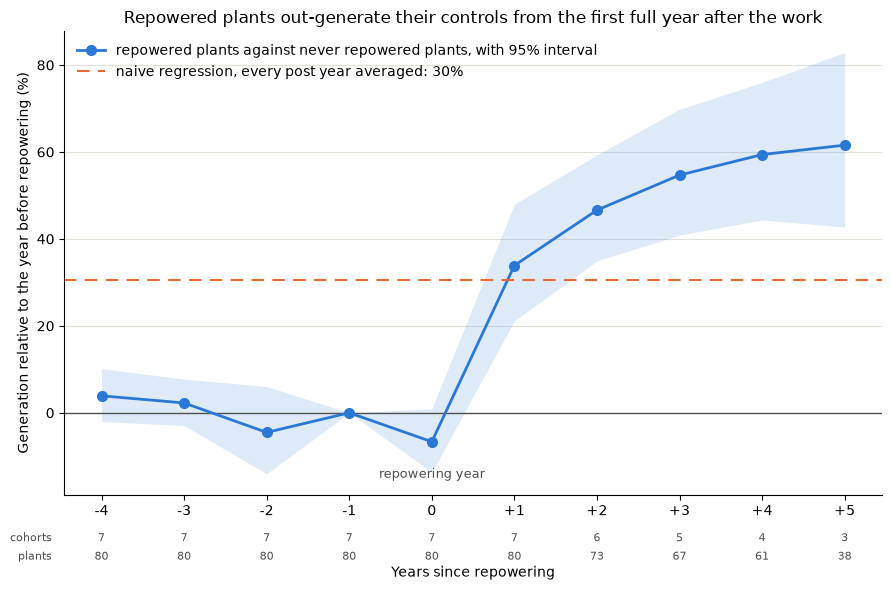

In [126]:
# The event study as a picture, in percent so it reads as generation rather than logs. The
# band is the 95% interval from the bootstrap, pointwise. The dashed line is the naive
# regression, which averages every post year including the transition year. Under the axis
# are the cohorts and plants behind each point, because the right-hand end of this chart
# rests on three cohorts and a reader should not have to guess that.
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

ev  = mart_event_study.set_index("rel_time")
pct = lambda x: 100 * (np.exp(x) - 1)

fig, ax = plt.subplots(figsize=(9, 6))
ax.axhline(0, color="#52514e", linewidth=1)
ax.fill_between(ev.index, pct(ev["ci_low"]), pct(ev["ci_high"]), color="#2a78d6", alpha=0.15, linewidth=0)
ax.plot(ev.index, pct(ev["att"]), color="#2a78d6", linewidth=2, marker="o", markersize=7,
        label="repowered plants against never repowered plants, with 95% interval")
ax.axhline(pct(twfe_beta), color="#eb6834", linewidth=1.5, linestyle=(0, (6, 4)),
           label=f"naive regression, every post year averaged: {pct(twfe_beta):.0f}%")
ax.annotate("repowering year", xy=(0, pct(ev.loc[0, "att"])), xytext=(0, -26), textcoords="offset points",
            ha="center", fontsize=9, color="#52514e")
ax.set_xticks(list(ev.index))
ax.set_xticklabels([f"{e:+d}" if e else "0" for e in ev.index])
ax.set_xlabel("Years since repowering", labelpad=34)
ax.set_ylabel("Generation relative to the year before repowering (%)")
ax.set_title("Repowered plants out-generate their controls from the first full year after the work")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False, loc="upper left")

trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
for e in ev.index:
    ax.text(e, -0.10, f"{int(ev.loc[e, 'cohorts'])}", transform=trans, ha="center", fontsize=8, color="#52514e")
    ax.text(e, -0.14, f"{int(ev.loc[e, 'plants'])}", transform=trans, ha="center", fontsize=8, color="#52514e")
ax.text(ev.index.min() - 0.6, -0.10, "cohorts", transform=trans, ha="right", fontsize=8, color="#52514e")
ax.text(ev.index.min() - 0.6, -0.14, "plants", transform=trans, ha="right", fontsize=8, color="#52514e")

plt.tight_layout()
plt.savefig("event_study.png", dpi=150, bbox_inches="tight")
plt.show()

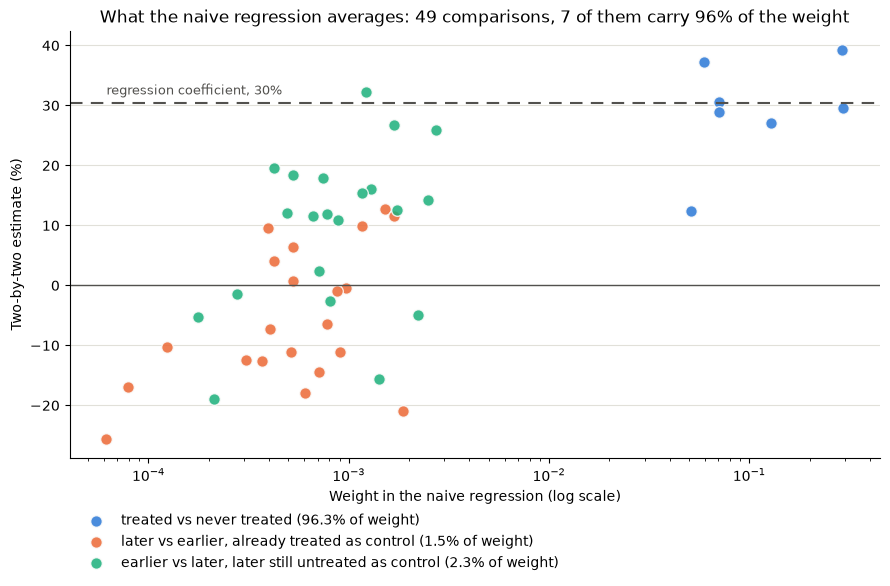

In [127]:
# The decomposition as a picture. Every point is one two-group, two-period comparison inside
# the naive regression, placed by the weight it carries and the estimate it returns; the
# weight axis is logarithmic because a handful of comparisons hold nearly all the weight and
# the rest would otherwise sit in a heap at zero. The dashed line is the regression
# coefficient, which is the weighted average of everything on the chart. The point of the
# picture is that the comparisons using already repowered plants as controls carry almost no
# weight here, so the regression survives this panel by having hundreds of never repowered
# controls, not by design, and a panel without them would not be so lucky.
colours = {"treated vs never treated": "#2a78d6",
           "later vs earlier, already treated as control": "#eb6834",
           "earlier vs later, later still untreated as control": "#1baf7a"}
clean = bacon[bacon["comparison"] == "treated vs never treated"]

fig, ax = plt.subplots(figsize=(9, 6))
ax.axhline(0, color="#52514e", linewidth=1)
for kind, colour in colours.items():
    sub = bacon[bacon["comparison"] == kind]
    ax.scatter(sub["weight"], pct(sub["estimate"]), s=70, color=colour, alpha=0.85,
               edgecolor="#fcfcfb", linewidth=1, label=f"{kind} ({100 * sub['weight'].sum():.1f}% of weight)")
ax.axhline(pct(twfe_beta), color="#52514e", linewidth=1.5, linestyle=(0, (6, 4)))
ax.annotate(f"regression coefficient, {pct(twfe_beta):.0f}%", xy=(bacon["weight"].min(), pct(twfe_beta)),
            xytext=(0, 6), textcoords="offset points", fontsize=9, color="#52514e")
ax.set_xscale("log")
ax.set_xlabel("Weight in the naive regression (log scale)")
ax.set_ylabel("Two-by-two estimate (%)")
ax.set_title(f"What the naive regression averages: {len(bacon)} comparisons, "
             f"{len(clean)} of them carry {100 * clean['weight'].sum():.0f}% of the weight")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0, -0.10), ncol=1)   # below the plot, clear of the points

plt.tight_layout()
plt.savefig("bacon_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

In [128]:
# The star schema for the dashboard, written out as four CSVs. The dashboard reads the same
# tables the estimate was built from, so a number on a visual traces back to a row here. The
# turbine fact is one row per turbine with typed columns; the plant dimension carries status,
# cohort, rotor class and whether the plant is in the study; the date dimension is one row
# per year so the year axis behaves like a date rather than a number. The export folder sits
# under the ignored data directory, because the dashboard file embeds its data and these
# files are a build input rather than a deliverable.
pbi_dir = Path("../data/powerbi/wind_repowering")
pbi_dir.mkdir(parents=True, exist_ok=True)

con.execute("""
    CREATE OR REPLACE TABLE fct_turbine AS
    SELECT case_id,
           TRY_CAST(eia_id AS INTEGER)                        AS plant_id,
           usgs_pr_id, p_name, t_state, t_county,
           TRY_CAST(p_year AS INTEGER)                        AS p_year,
           t_manu, t_model,
           TRY_CAST(t_cap AS DOUBLE)                          AS t_cap_kw,
           TRY_CAST(t_hh AS DOUBLE)                           AS t_hh_m,
           TRY_CAST(t_rd AS DOUBLE)                           AS t_rd_m,
           TRY_CAST(t_rsa AS DOUBLE)                          AS t_rsa_m2,
           t_retrofit = '1'                                   AS retrofitted,
           TRY_CAST(t_retro_yr AS INTEGER)                    AS retrofit_year,
           (t_retrofit = '1' AND p_year = t_retro_yr)         AS build_year_rewritten,
           TRY_CAST(xlong AS DOUBLE)                          AS longitude,
           TRY_CAST(ylat AS DOUBLE)                           AS latitude
    FROM raw_turbines_current
""")
con.execute("""
    CREATE OR REPLACE TABLE dim_plant_export AS
    WITH study AS (
        SELECT DISTINCT plant_id FROM panel_balanced
        WHERE status = 'control' OR cohort_year BETWEEN 2017 AND 2023
    )
    SELECT s.plant_id, s.t_state AS state, s.status, s.cohort_year,
           s.first_p_year AS build_year, s.build_year_rewritten,
           s.n_turbines, s.n_retrofitted, s.total_cap_mw, s.control_eligible,
           (st.plant_id IS NOT NULL)                          AS in_study,
           CASE WHEN r.rotor_change_pct > 2  THEN 'rotor grew'
                WHEN r.rotor_change_pct IS NULL THEN 'unknown'
                ELSE 'rotor unchanged or smaller' END         AS rotor_class,
           r.rotor_m_2018, r.rotor_m_today, r.rotor_change_pct
    FROM plant_scope s
    LEFT JOIN plant_rotor r USING (plant_id)
    LEFT JOIN study st USING (plant_id)
""")
con.execute("""
    CREATE OR REPLACE TABLE dim_date AS
    SELECT CAST(year AS INTEGER) AS year,
           MAKE_DATE(CAST(year AS INTEGER), 1, 1) AS year_start,
           year >= 2025 AS provisional
    FROM range(2013, 2026) AS t(year)
""")
for name, source_table in [("dim_plant", "dim_plant_export"), ("dim_date", "dim_date"),
                           ("fct_generation_plant_year", "fct_generation_plant_year"), ("fct_turbine", "fct_turbine")]:
    con.execute("COPY " + source_table + " TO '" + (pbi_dir / (name + ".csv")).as_posix() + "' (HEADER)")
    n_rows = con.execute("SELECT COUNT(*) FROM " + source_table).fetchone()[0]
    print(f"{name:<28} {n_rows:>7} rows")

dim_plant                       1327 rows
dim_date                          13 rows
fct_generation_plant_year      14077 rows
fct_turbine                    75727 rows


In [129]:
# The checks this notebook made along the way, gathered into one table so a reader can see
# every rule, what it expected, what it found and what was done about it without scrolling
# through eighty cells. Each rule is a query that counts the rows failing it. The expected
# values are the ones measured on this pull, so a re-pull that moves any of them shows up
# here first. Three severities: a block stops the build until a decision is written, a warn
# is flagged and carried, a note is recorded and nothing more. One check, the monthly
# against annual reconciliation, was made in pandas before the fact table existed, so its
# count comes from that frame rather than from a query.
study_plants = "SELECT DISTINCT plant_id FROM panel_balanced WHERE status = 'control' OR cohort_year BETWEEN 2017 AND 2023"
checks = [
    ("B1",  "BLOCK", "duplicate case_id in the current turbine pull", 0,
     "SELECT COUNT(*) FROM (SELECT case_id FROM raw_turbines_current GROUP BY 1 HAVING COUNT(*) > 1)",
     "stop if any"),
    ("B2",  "WARN",  "turbine with no plant id, so it can never reach the generation data", 3615,
     "SELECT COUNT(*) FROM raw_turbines_current WHERE NULLIF(TRIM(eia_id), '') IS NULL",
     "excluded; 2.4% of capacity"),
    ("B3a", "WARN",  "turbine capacity missing", "about 4.3%",
     "SELECT COUNT(*) FROM raw_turbines_current WHERE NULLIF(TRIM(t_cap), '') IS NULL",
     "carried as null; plant capacity sums understated where present"),
    ("B3b", "WARN",  "rotor diameter missing", "about 4.7%",
     "SELECT COUNT(*) FROM raw_turbines_current WHERE NULLIF(TRIM(t_rd), '') IS NULL",
     "carried as null"),
    ("B3c", "WARN",  "build year missing", "about 1.5%",
     "SELECT COUNT(*) FROM raw_turbines_current WHERE NULLIF(TRIM(p_year), '') IS NULL",
     "carried as null; plant build year is the minimum over its turbines"),
    ("B4",  "BLOCK", "retrofitted turbine with no retrofit year", 0,
     "SELECT COUNT(*) FROM raw_turbines_current WHERE t_retrofit = '1' AND NULLIF(TRIM(t_retro_yr), '') IS NULL",
     "stop if any"),
    ("B5",  "WARN",  "build year rewritten to the retrofit year on a retrofitted turbine", 1529,
     "SELECT COUNT(*) FROM raw_turbines_current WHERE t_retrofit = '1' AND p_year = t_retro_yr",
     "17 plants; their build year does not set the vintage window"),
    ("B6",  "BLOCK", "plant holding both retrofitted and untouched turbines", 29,
     "SELECT COUNT(*) FROM plant_scope WHERE status = 'mixed'",
     "set aside; counted as treated in a sensitivity"),
    ("B7",  "WARN",  "treated plant with retrofits in more than one year", 0,
     "SELECT COUNT(*) FROM plant_scope WHERE status = 'treated' AND n_retrofit_years > 1",
     "none exist, so the planned sensitivity is moot"),
    ("B8",  "BLOCK", "generation years missing after the rename map (of 13)", 0,
     "SELECT 13 - COUNT(DISTINCT year) FROM fct_generation_plant_year",
     "the loader stops and names the year"),
    ("B9",  "WARN",  "plant-year with net generation at or below zero", "measure",
     "SELECT COUNT(*) FROM fct_generation_plant_year WHERE net_gen_mwh <= 0",
     "kept in levels, null in logs, fails the balance test"),
    ("B10", "WARN",  "plant in the panel without twelve positive years", 53,
     "SELECT COUNT(*) FROM (SELECT DISTINCT plant_id FROM panel EXCEPT SELECT DISTINCT plant_id FROM panel_balanced)",
     "primary estimate on the balanced set; unbalanced as sensitivity"),
    ("B11", "WARN",  "plant in scope with no generation record 2013 to 2024", 18,
     "SELECT COUNT(*) FROM plant_scope WHERE (status = 'treated' OR control_eligible) "
     "AND plant_id NOT IN (SELECT DISTINCT plant_id FROM fct_generation_plant_year WHERE year BETWEEN 2013 AND 2024)",
     "excluded; 1 treated and 17 controls"),
    ("B12", "NOTE",  "plant-year built from more than one wind row", 11,
     "SELECT COUNT(*) FROM fct_generation_plant_year WHERE rows_summed > 1",
     "summed"),
    ("B13", "WARN",  "treated plant in a cohort outside 2017 to 2023", 10,
     "SELECT COUNT(*) FROM plant_scope WHERE status = 'treated' AND cohort_year NOT BETWEEN 2017 AND 2023",
     "dropped: 2015 is one plant, 2024 has no year after treatment"),
    ("B14", "NOTE",  "plants filing in the provisional 2025 release", 624,
     "SELECT COUNT(DISTINCT plant_id) FROM fct_generation_plant_year WHERE year = 2025",
     "2025 kept in the fact table, excluded from the panel; 1,348 filed in 2024"),
    ("B15", "WARN",  "treated plant in the study with no 2018 rotor record", 4,
     "SELECT COUNT(*) FROM (" + study_plants + ") s JOIN plant_scope p USING (plant_id) "
     "WHERE p.status = 'treated' AND p.plant_id NOT IN (SELECT plant_id FROM plant_rotor)",
     "rotor class unknown; reported separately and dropped in a sensitivity"),
    ("B16", "WARN",  "generation row with a dot where the year should be", 19,
     "SELECT COUNT(*) FROM dq_generation_quarantine",
     "quarantined, not dropped"),
    ("B17", "NOTE",  "generation row whose twelve months disagree with its annual total by over 1 MWh", 0,
     int(gen["mismatch"].sum()),
     "none; the annual column is the one used"),
]
rows = []
for check_id, severity, rule, expected, query, decision in checks:
    failing = query if isinstance(query, int) else con.execute(query).fetchone()[0]
    rows.append({"id": check_id, "severity": severity, "rule": rule, "expected": str(expected),
                 "failing_rows": int(failing), "decision": decision})
dq_assertions = pd.DataFrame(rows)
con.register("dq_assertions_df", dq_assertions)
con.execute("CREATE OR REPLACE TABLE dq_assertions AS SELECT * FROM dq_assertions_df")
print(dq_assertions.to_string(index=False))

 id severity                                                                            rule   expected  failing_rows                                                                  decision
 B1    BLOCK                                   duplicate case_id in the current turbine pull          0             0                                                               stop if any
 B2     WARN             turbine with no plant id, so it can never reach the generation data       3615          3615                                                excluded; 2.4% of capacity
B3a     WARN                                                        turbine capacity missing about 4.3%          3282            carried as null; plant capacity sums understated where present
B3b     WARN                                                          rotor diameter missing about 4.7%          3527                                                           carried as null
B3c     WARN                            